In [64]:
#Imports
import pandas as pd
import numpy as np
from scipy.stats import f,t
# from google.colab import files
from sklearn.model_selection import train_test_split, KFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso, LassoCV, LinearRegression
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import OLSInfluence

In [65]:
# Add Dataset
#uploaded = files.upload()
df_housing = pd.read_csv('Revised - Merged Housing Dataset (by ZipCode).csv')
df_stab = pd.read_csv('/Users/minseokcho/Desktop/github/New DSA/NYC-DSA/datasets/final-usables/final_zip_stabilization_dataset.csv')
# df_pluto_stab = pd.read_csv('pluto_with_rent_stabilization_flag.csv')
#Data Setup

In [66]:
pd.set_option('display.max_columns', None)

In [67]:
df_housing.sort_values('rent_not_computed', ascending=False)

,Unnamed: 0,geoid,zip,borough,rent_burden_total_renter_households,rent_lt_10pct_income,rent_10_to_14_9pct_income,rent_15_to_19_9pct_income,rent_20_to_24_9pct_income,rent_25_to_29_9pct_income,rent_30_to_34_9pct_income,rent_35_to_39_9pct_income,rent_40_to_49_9pct_income,rent_50pct_or_more_income,rent_not_computed,housing_units_total,median_gross_rent,median_household_income,occupancy_total_units,occupied_units,vacant_units,tenure_total_occupied_units,owner_occupied_units,renter_occupied_units,total_population,year_built_total_units,built_2020_or_later,built_2010_2019,built_2000_2009,built_1990_1999,built_1980_1989,built_1970_1979,built_1960_1969,built_1950_1959,built_1940_1949,built_1939_or_earlier
84,115,86000US10453,10453,Bronx,26922.0,1123.0,1707.0,1983.0,1768.0,1927.0,1720.0,1734.0,2255.0,10286.0,2419.0,28564.0,1420.0,33186.0,28564.0,28279.0,285.0,28279.0,1357.0,26922.0,76282.0,28564.0,153.0,1919.0,1869.0,1500.0,2409.0,3572.0,2625.0,2765.0,2471.0,9281.0
118,164,86000US11207,11207,Brooklyn,26405.0,1321.0,1876.0,2249.0,2854.0,2371.0,2398.0,1708.0,1939.0,7510.0,2179.0,38824.0,1482.0,56523.0,38824.0,35658.0,3166.0,35658.0,9253.0,26405.0,93198.0,38824.0,345.0,2903.0,3243.0,3524.0,1859.0,2257.0,3981.0,3802.0,2864.0,14046.0
152,198,86000US11355,11355,Queens,20690.0,557.0,1369.0,1872.0,1692.0,1007.0,1657.0,1886.0,1771.0,6765.0,2114.0,32362.0,1725.0,55326.0,32362.0,31078.0,1284.0,31078.0,10388.0,20690.0,80801.0,32362.0,271.0,1482.0,1800.0,1840.0,2732.0,2729.0,6242.0,6952.0,2840.0,5474.0
98,129,86000US10467,10467,Bronx,32910.0,1069.0,1601.0,3759.0,3082.0,3477.0,2530.0,1853.0,2586.0,10930.0,2023.0,40791.0,1522.0,49330.0,40791.0,38372.0,2419.0,38372.0,5462.0,32910.0,96421.0,40791.0,186.0,1966.0,1770.0,961.0,1253.0,2622.0,4905.0,5645.0,4631.0,16852.0
119,165,86000US11208,11208,Brooklyn,25836.0,2216.0,1779.0,2442.0,2475.0,2188.0,1630.0,1774.0,1979.0,7574.0,1779.0,36994.0,1651.0,62077.0,36994.0,34395.0,2599.0,34395.0,8559.0,25836.0,105428.0,36994.0,102.0,1750.0,2348.0,1868.0,2083.0,2252.0,3064.0,3761.0,2907.0,16859.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,92,86000US10174,10174,Manhattan,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
62,93,86000US10177,10177,Manhattan,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
53,84,86000US10165,10165,Manhattan,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
63,94,86000US10199,10199,Manhattan,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [68]:
df_housing

,Unnamed: 0,geoid,zip,borough,rent_burden_total_renter_households,rent_lt_10pct_income,rent_10_to_14_9pct_income,rent_15_to_19_9pct_income,rent_20_to_24_9pct_income,rent_25_to_29_9pct_income,rent_30_to_34_9pct_income,rent_35_to_39_9pct_income,rent_40_to_49_9pct_income,rent_50pct_or_more_income,rent_not_computed,housing_units_total,median_gross_rent,median_household_income,occupancy_total_units,occupied_units,vacant_units,tenure_total_occupied_units,owner_occupied_units,renter_occupied_units,total_population,year_built_total_units,built_2020_or_later,built_2010_2019,built_2000_2009,built_1990_1999,built_1980_1989,built_1970_1979,built_1960_1969,built_1950_1959,built_1940_1949,built_1939_or_earlier
0,31,86000US10001,10001,Manhattan,11939.0,917.0,1502.0,1801.0,1484.0,1181.0,1074.0,546.0,892.0,2137.0,405.0,18356.0,3361.0,129852.0,18356.0,15737.0,2619.0,15737.0,3798.0,11939.0,30511.0,18356.0,280.0,5049.0,2404.0,296.0,590.0,423.0,3290.0,553.0,508.0,4963.0
1,32,86000US10002,10002,Manhattan,29732.0,1688.0,2438.0,2857.0,3466.0,3197.0,3752.0,1338.0,2076.0,7758.0,1162.0,40696.0,1229.0,48386.0,40696.0,36556.0,4140.0,36556.0,6824.0,29732.0,76873.0,40696.0,403.0,1940.0,1590.0,1313.0,2373.0,3566.0,4822.0,6003.0,2838.0,15848.0
2,33,86000US10003,10003,Manhattan,15410.0,1031.0,2255.0,1722.0,1455.0,1355.0,1147.0,1171.0,1148.0,3480.0,646.0,30413.0,3049.0,154262.0,30413.0,24503.0,5910.0,24503.0,9093.0,15410.0,53560.0,30413.0,50.0,683.0,989.0,558.0,1555.0,1560.0,4611.0,2456.0,1425.0,16526.0
3,34,86000US10004,10004,Manhattan,1060.0,21.0,119.0,255.0,84.0,39.0,128.0,72.0,136.0,206.0,0.0,2247.0,3501.0,250001.0,2247.0,1865.0,382.0,1865.0,805.0,1060.0,3711.0,2247.0,0.0,221.0,421.0,44.0,115.0,18.0,33.0,5.0,6.0,1384.0
4,35,86000US10005,10005,Manhattan,4323.0,77.0,515.0,461.0,664.0,559.0,364.0,188.0,331.0,1164.0,0.0,6606.0,3501.0,190233.0,6606.0,5248.0,1358.0,5248.0,925.0,4323.0,9439.0,6606.0,0.0,161.0,841.0,601.0,125.0,515.0,393.0,339.0,218.0,3413.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
207,253,86000US11691,11691,Queens,16665.0,1049.0,1126.0,915.0,1993.0,1893.0,1332.0,1320.0,1426.0,4702.0,909.0,24072.0,1425.0,56135.0,24072.0,23039.0,1033.0,23039.0,6374.0,16665.0,69359.0,24072.0,276.0,925.0,2531.0,1196.0,1430.0,4074.0,3541.0,4225.0,1461.0,4413.0
208,254,86000US11692,11692,Queens,5400.0,342.0,471.0,405.0,408.0,251.0,426.0,560.0,412.0,1734.0,391.0,8415.0,1161.0,49720.0,8415.0,8070.0,345.0,8070.0,2670.0,5400.0,22734.0,8415.0,135.0,1175.0,1307.0,361.0,275.0,1368.0,1223.0,1205.0,382.0,984.0
209,255,86000US11693,11693,Queens,2847.0,112.0,238.0,240.0,301.0,375.0,220.0,87.0,171.0,907.0,196.0,5922.0,1216.0,68449.0,5922.0,5559.0,363.0,5559.0,2712.0,2847.0,13244.0,5922.0,0.0,377.0,811.0,406.0,71.0,495.0,1128.0,997.0,520.0,1117.0
210,256,86000US11694,11694,Queens,3963.0,310.0,263.0,685.0,572.0,284.0,332.0,276.0,127.0,816.0,298.0,9078.0,1757.0,111011.0,9078.0,8165.0,913.0,8165.0,4202.0,3963.0,21489.0,9078.0,44.0,260.0,1090.0,177.0,329.0,592.0,2108.0,1046.0,560.0,2872.0


In [69]:
df_stab

,zipcode,total_units,stabilized_units,stabilized_buildings,total_buildings,stabilization_share
0,10001,22303.0,12310.0,127,356,0.551944
1,10002,36840.0,14431.0,601,1180,0.391721
2,10003,33576.0,18652.0,602,1479,0.555516
3,10004,4492.0,1248.0,5,37,0.277827
4,10005,6871.0,2923.0,8,25,0.425411
...,...,...,...,...,...,...
181,11692,8348.0,83.0,16,2083,0.009943
182,11693,4727.0,340.0,48,1526,0.071927
183,11694,9553.0,1423.0,29,3513,0.148958
184,11697,2837.0,0.0,0,3,0.000000


In [70]:
# DATA PREP
df_housing['zip'] = pd.to_numeric(df_housing['zip'], errors='coerce')
df_housing = df_housing.dropna(subset=['zip'])
df_housing['zip'] = df_housing['zip'].astype(int)

#Merges data on shared components
df_merged = pd.merge(df_housing, df_stab, left_on='zip',right_on ='zipcode', how='inner')

# FEATURE ENGINEERING
# Calculate Housing Supply with Vacancy Rate
df_merged['vacancy_rate'] = df_merged['vacant_units'] / df_merged['housing_units_total']

# Homeownership Rate
df_merged['homeownership_rate'] = df_merged['owner_occupied_units'] / df_merged['housing_units_total']

# Construction Share (Everything built 2010 or later)
df_merged['new_construction_share'] = (df_merged['built_2020_or_later'] + df_merged['built_2010_2019']) / df_merged['housing_units_total']

# Renter Density (Share of units occupied by renters)
df_merged['renter_density'] = df_merged['renter_occupied_units'] / df_merged['housing_units_total']

# Pre-War Building Share (Built 1939 or earlier)
df_merged['pre_war_share'] = df_merged['built_1939_or_earlier'] / df_merged['housing_units_total']

df_merged.columns

Index(['Unnamed: 0', 'geoid', 'zip', 'borough',
       'rent_burden_total_renter_households', 'rent_lt_10pct_income',
       'rent_10_to_14_9pct_income', 'rent_15_to_19_9pct_income',
       'rent_20_to_24_9pct_income', 'rent_25_to_29_9pct_income',
       'rent_30_to_34_9pct_income', 'rent_35_to_39_9pct_income',
       'rent_40_to_49_9pct_income', 'rent_50pct_or_more_income',
       'rent_not_computed', 'housing_units_total', 'median_gross_rent',
       'median_household_income', 'occupancy_total_units', 'occupied_units',
       'vacant_units', 'tenure_total_occupied_units', 'owner_occupied_units',
       'renter_occupied_units', 'total_population', 'year_built_total_units',
       'built_2020_or_later', 'built_2010_2019', 'built_2000_2009',
       'built_1990_1999', 'built_1980_1989', 'built_1970_1979',
       'built_1960_1969', 'built_1950_1959', 'built_1940_1949',
       'built_1939_or_earlier', 'zipcode', 'total_units', 'stabilized_units',
       'stabilized_buildings', 'total_build

# MC work

In [71]:
df_merged.shape

(178, 47)

In [72]:
def zip_to_borough(z):
    if 10451 <= z <= 10475: return 'Bronx'
    if (11201 <= z <= 11256) or (11001 <= z <= 11003): return 'Brooklyn'
    if 10001 <= z <= 10282: return 'Manhattan'
    if (11004 <= z <= 11109) or (11351 <= z <= 11697): return 'Queens'
    if 10301 <= z <= 10314: return 'Staten Island'
    return 'Unknown'

df_merged['borough'] = df_merged['zip'].apply(zip_to_borough)

df_merged

,Unnamed: 0,geoid,zip,borough,rent_burden_total_renter_households,rent_lt_10pct_income,rent_10_to_14_9pct_income,rent_15_to_19_9pct_income,rent_20_to_24_9pct_income,rent_25_to_29_9pct_income,rent_30_to_34_9pct_income,rent_35_to_39_9pct_income,rent_40_to_49_9pct_income,rent_50pct_or_more_income,rent_not_computed,housing_units_total,median_gross_rent,median_household_income,occupancy_total_units,occupied_units,vacant_units,tenure_total_occupied_units,owner_occupied_units,renter_occupied_units,total_population,year_built_total_units,built_2020_or_later,built_2010_2019,built_2000_2009,built_1990_1999,built_1980_1989,built_1970_1979,built_1960_1969,built_1950_1959,built_1940_1949,built_1939_or_earlier,zipcode,total_units,stabilized_units,stabilized_buildings,total_buildings,stabilization_share,vacancy_rate,homeownership_rate,new_construction_share,renter_density,pre_war_share
0,31,86000US10001,10001,Manhattan,11939.0,917.0,1502.0,1801.0,1484.0,1181.0,1074.0,546.0,892.0,2137.0,405.0,18356.0,3361.0,129852.0,18356.0,15737.0,2619.0,15737.0,3798.0,11939.0,30511.0,18356.0,280.0,5049.0,2404.0,296.0,590.0,423.0,3290.0,553.0,508.0,4963.0,10001,22303.0,12310.0,127,356,0.551944,0.142678,0.206908,0.290314,0.650414,0.270375
1,32,86000US10002,10002,Manhattan,29732.0,1688.0,2438.0,2857.0,3466.0,3197.0,3752.0,1338.0,2076.0,7758.0,1162.0,40696.0,1229.0,48386.0,40696.0,36556.0,4140.0,36556.0,6824.0,29732.0,76873.0,40696.0,403.0,1940.0,1590.0,1313.0,2373.0,3566.0,4822.0,6003.0,2838.0,15848.0,10002,36840.0,14431.0,601,1180,0.391721,0.101730,0.167682,0.057573,0.730588,0.389424
2,33,86000US10003,10003,Manhattan,15410.0,1031.0,2255.0,1722.0,1455.0,1355.0,1147.0,1171.0,1148.0,3480.0,646.0,30413.0,3049.0,154262.0,30413.0,24503.0,5910.0,24503.0,9093.0,15410.0,53560.0,30413.0,50.0,683.0,989.0,558.0,1555.0,1560.0,4611.0,2456.0,1425.0,16526.0,10003,33576.0,18652.0,602,1479,0.555516,0.194325,0.298984,0.024102,0.506691,0.543386
3,34,86000US10004,10004,Manhattan,1060.0,21.0,119.0,255.0,84.0,39.0,128.0,72.0,136.0,206.0,0.0,2247.0,3501.0,250001.0,2247.0,1865.0,382.0,1865.0,805.0,1060.0,3711.0,2247.0,0.0,221.0,421.0,44.0,115.0,18.0,33.0,5.0,6.0,1384.0,10004,4492.0,1248.0,5,37,0.277827,0.170004,0.358255,0.098353,0.471740,0.615932
4,35,86000US10005,10005,Manhattan,4323.0,77.0,515.0,461.0,664.0,559.0,364.0,188.0,331.0,1164.0,0.0,6606.0,3501.0,190233.0,6606.0,5248.0,1358.0,5248.0,925.0,4323.0,9439.0,6606.0,0.0,161.0,841.0,601.0,125.0,515.0,393.0,339.0,218.0,3413.0,10005,6871.0,2923.0,8,25,0.425411,0.205571,0.140024,0.024372,0.654405,0.516652
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,253,86000US11691,11691,Queens,16665.0,1049.0,1126.0,915.0,1993.0,1893.0,1332.0,1320.0,1426.0,4702.0,909.0,24072.0,1425.0,56135.0,24072.0,23039.0,1033.0,23039.0,6374.0,16665.0,69359.0,24072.0,276.0,925.0,2531.0,1196.0,1430.0,4074.0,3541.0,4225.0,1461.0,4413.0,11691,24882.0,9036.0,156,5608,0.363154,0.042913,0.264789,0.049892,0.692298,0.183325
174,254,86000US11692,11692,Queens,5400.0,342.0,471.0,405.0,408.0,251.0,426.0,560.0,412.0,1734.0,391.0,8415.0,1161.0,49720.0,8415.0,8070.0,345.0,8070.0,2670.0,5400.0,22734.0,8415.0,135.0,1175.0,1307.0,361.0,275.0,1368.0,1223.0,1205.0,382.0,984.0,11692,8348.0,83.0,16,2083,0.009943,0.040998,0.317291,0.155674,0.641711,0.116934
175,255,86000US11693,11693,Queens,2847.0,112.0,238.0,240.0,301.0,375.0,220.0,87.0,171.0,907.0,196.0,5922.0,1216.0,68449.0,5922.0,5559.0,363.0,5559.0,2712.0,2847.0,13244.0,5922.0,0.0,377.0,811.0,406.0,71.0,495.0,1128.0,997.0,520.0,1117.0,11693,4727.0,340.0,48,1526,0.071927,0.061297,0.457953,0.063661,0.480750,0.188619
176,256,86000US11694,11694,Queens,3963.0,310.0,263.0,685.0,572.0,284.0,332.0,276.0,127.0,816.0,298.0,9078.0,1757.0,111011.0,9078.0,8165.0,913.0,8165.0,4202.0,3963.0,21489.0,9078.0,44.0,260.0,1090.0,177.0,329.0,592.0,2108.0,1046.0,560.0,2872.0,11694,9553.0,1423.0,29,3513,0.1

In [73]:
df_merged[df_merged['borough'] == 'Unknown']
#GOOD CLEAN - NOTHING IS MISSING

,Unnamed: 0,geoid,zip,borough,rent_burden_total_renter_households,rent_lt_10pct_income,rent_10_to_14_9pct_income,rent_15_to_19_9pct_income,rent_20_to_24_9pct_income,rent_25_to_29_9pct_income,rent_30_to_34_9pct_income,rent_35_to_39_9pct_income,rent_40_to_49_9pct_income,rent_50pct_or_more_income,rent_not_computed,housing_units_total,median_gross_rent,median_household_income,occupancy_total_units,occupied_units,vacant_units,tenure_total_occupied_units,owner_occupied_units,renter_occupied_units,total_population,year_built_total_units,built_2020_or_later,built_2010_2019,built_2000_2009,built_1990_1999,built_1980_1989,built_1970_1979,built_1960_1969,built_1950_1959,built_1940_1949,built_1939_or_earlier,zipcode,total_units,stabilized_units,stabilized_buildings,total_buildings,stabilization_share,vacancy_rate,homeownership_rate,new_construction_share,renter_density,pre_war_share


# Lasso

# Convert boroughs to dummies

In [74]:
borough_dummies = pd.get_dummies(df_merged['borough'], prefix='borough', drop_first=True).astype(float)
borough_dummies.columns = borough_dummies.columns.str.replace(' ', '_')
df_merged = pd.concat([df_merged, borough_dummies], axis=1)

df_merged

,Unnamed: 0,geoid,zip,borough,rent_burden_total_renter_households,rent_lt_10pct_income,rent_10_to_14_9pct_income,rent_15_to_19_9pct_income,rent_20_to_24_9pct_income,rent_25_to_29_9pct_income,rent_30_to_34_9pct_income,rent_35_to_39_9pct_income,rent_40_to_49_9pct_income,rent_50pct_or_more_income,rent_not_computed,housing_units_total,median_gross_rent,median_household_income,occupancy_total_units,occupied_units,vacant_units,tenure_total_occupied_units,owner_occupied_units,renter_occupied_units,total_population,year_built_total_units,built_2020_or_later,built_2010_2019,built_2000_2009,built_1990_1999,built_1980_1989,built_1970_1979,built_1960_1969,built_1950_1959,built_1940_1949,built_1939_or_earlier,zipcode,total_units,stabilized_units,stabilized_buildings,total_buildings,stabilization_share,vacancy_rate,homeownership_rate,new_construction_share,renter_density,pre_war_share,borough_Brooklyn,borough_Manhattan,borough_Queens,borough_Staten_Island
0,31,86000US10001,10001,Manhattan,11939.0,917.0,1502.0,1801.0,1484.0,1181.0,1074.0,546.0,892.0,2137.0,405.0,18356.0,3361.0,129852.0,18356.0,15737.0,2619.0,15737.0,3798.0,11939.0,30511.0,18356.0,280.0,5049.0,2404.0,296.0,590.0,423.0,3290.0,553.0,508.0,4963.0,10001,22303.0,12310.0,127,356,0.551944,0.142678,0.206908,0.290314,0.650414,0.270375,0.0,1.0,0.0,0.0
1,32,86000US10002,10002,Manhattan,29732.0,1688.0,2438.0,2857.0,3466.0,3197.0,3752.0,1338.0,2076.0,7758.0,1162.0,40696.0,1229.0,48386.0,40696.0,36556.0,4140.0,36556.0,6824.0,29732.0,76873.0,40696.0,403.0,1940.0,1590.0,1313.0,2373.0,3566.0,4822.0,6003.0,2838.0,15848.0,10002,36840.0,14431.0,601,1180,0.391721,0.101730,0.167682,0.057573,0.730588,0.389424,0.0,1.0,0.0,0.0
2,33,86000US10003,10003,Manhattan,15410.0,1031.0,2255.0,1722.0,1455.0,1355.0,1147.0,1171.0,1148.0,3480.0,646.0,30413.0,3049.0,154262.0,30413.0,24503.0,5910.0,24503.0,9093.0,15410.0,53560.0,30413.0,50.0,683.0,989.0,558.0,1555.0,1560.0,4611.0,2456.0,1425.0,16526.0,10003,33576.0,18652.0,602,1479,0.555516,0.194325,0.298984,0.024102,0.506691,0.543386,0.0,1.0,0.0,0.0
3,34,86000US10004,10004,Manhattan,1060.0,21.0,119.0,255.0,84.0,39.0,128.0,72.0,136.0,206.0,0.0,2247.0,3501.0,250001.0,2247.0,1865.0,382.0,1865.0,805.0,1060.0,3711.0,2247.0,0.0,221.0,421.0,44.0,115.0,18.0,33.0,5.0,6.0,1384.0,10004,4492.0,1248.0,5,37,0.277827,0.170004,0.358255,0.098353,0.471740,0.615932,0.0,1.0,0.0,0.0
4,35,86000US10005,10005,Manhattan,4323.0,77.0,515.0,461.0,664.0,559.0,364.0,188.0,331.0,1164.0,0.0,6606.0,3501.0,190233.0,6606.0,5248.0,1358.0,5248.0,925.0,4323.0,9439.0,6606.0,0.0,161.0,841.0,601.0,125.0,515.0,393.0,339.0,218.0,3413.0,10005,6871.0,2923.0,8,25,0.425411,0.205571,0.140024,0.024372,0.654405,0.516652,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,253,86000US11691,11691,Queens,16665.0,1049.0,1126.0,915.0,1993.0,1893.0,1332.0,1320.0,1426.0,4702.0,909.0,24072.0,1425.0,56135.0,24072.0,23039.0,1033.0,23039.0,6374.0,16665.0,69359.0,24072.0,276.0,925.0,2531.0,1196.0,1430.0,4074.0,3541.0,4225.0,1461.0,4413.0,11691,24882.0,9036.0,156,5608,0.363154,0.042913,0.264789,0.049892,0.692298,0.183325,0.0,0.0,1.0,0.0
174,254,86000US11692,11692,Queens,5400.0,342.0,471.0,405.0,408.0,251.0,426.0,560.0,412.0,1734.0,391.0,8415.0,1161.0,49720.0,8415.0,8070.0,345.0,8070.0,2670.0,5400.0,22734.0,8415.0,135.0,1175.0,1307.0,361.0,275.0,1368.0,1223.0,1205.0,382.0,984.0,11692,8348.0,83.0,16,2083,0.009943,0.040998,0.317291,0.155674,0.641711,0.116934,0.0,0.0,1.0,0.0
175,255,86000US11693,11693,Queens,2847.0,112.0,238.0,240.0,301.0,375.0,220.0,87.0,171.0,907.0,196.0,5922.0,1216.0,68449.0,5922.0,5559.0,363.0,5559.0,2712.0,2847.0,13244.0,5922.0,0.0,377.0,811.0,406.0,71.0,495.0,1128.0,997.0,520.0,1117.0,11693,4727.0,340.0,48,1526,0.071927,0.061297,0.457953,0.063661,0.480750,0.188619,0.0,0.0,1.0,0.0
176,256,86000US11694,11694,Queens,3963.0,310.0,263.0,685.0

In [75]:
feature_columns = [
    'rent_burden_total_renter_households', 'rent_lt_10pct_income',
    'rent_10_to_14_9pct_income', 'rent_15_to_19_9pct_income',
    'rent_20_to_24_9pct_income', 'rent_25_to_29_9pct_income',
    'rent_30_to_34_9pct_income', 'rent_35_to_39_9pct_income',
    'rent_40_to_49_9pct_income', 'rent_50pct_or_more_income',
    #'rent_not_computed', 
    'housing_units_total', 'median_gross_rent',
    'median_household_income', 'occupancy_total_units', 'occupied_units',
    'vacant_units', 'tenure_total_occupied_units', 'owner_occupied_units',
    'renter_occupied_units', 'total_population', 'year_built_total_units',
    'built_2020_or_later', 'built_2010_2019', 'built_2000_2009',
    'built_1990_1999', 'built_1980_1989', 'built_1970_1979',
    'built_1960_1969', 'built_1950_1959', 'built_1940_1949',
    'built_1939_or_earlier', 
    'total_units', 'stabilized_units',
    'stabilized_buildings', 'total_buildings', 'stabilization_share',
    'vacancy_rate', 'homeownership_rate', 'new_construction_share',
    'renter_density', 'pre_war_share', 
    #changed zipcode to borough
    'borough_Brooklyn', 'borough_Manhattan', 'borough_Queens', 
    'borough_Staten_Island'
    #Bronx is the base dummy
]

# Split

In [76]:
# Train test split
df_model = df_merged[feature_columns].replace([np.inf, -np.inf], np.nan).dropna()

# Check how many rows were dropped
original = len(df_merged)
cleaned  = len(df_model)
print(f"Rows dropped : {original - cleaned}")
print(f"Rows kept    : {cleaned} / {original} ({cleaned/original*100:.1f}%)")

# ======================================================================
# 2. TRAIN TEST SPLIT
# ======================================================================
X = df_model.drop(columns=['median_gross_rent'])
Y = df_model['median_gross_rent'].values

X_train, X_test, Y_train, Y_test = train_test_split(
    X.values, Y, test_size=0.20, random_state=42
)

Rows dropped : 3
Rows kept    : 175 / 178 (98.3%)


## Lasso - Find Best Alpha through CV

In [77]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on train only
X_test_scaled  = scaler.transform(X_test)        # transform test with same scaler

lasso_cv = LassoCV(
    alphas=np.logspace(-3, 4, 100),
    cv=5,
    random_state=42,
    max_iter=100000
)
lasso_cv.fit(X_train_scaled, Y_train)  # now fitted on scaled data

print(f"Best alpha (lambda): {lasso_cv.alpha_:.4f}")

Best alpha (lambda): 12.6186


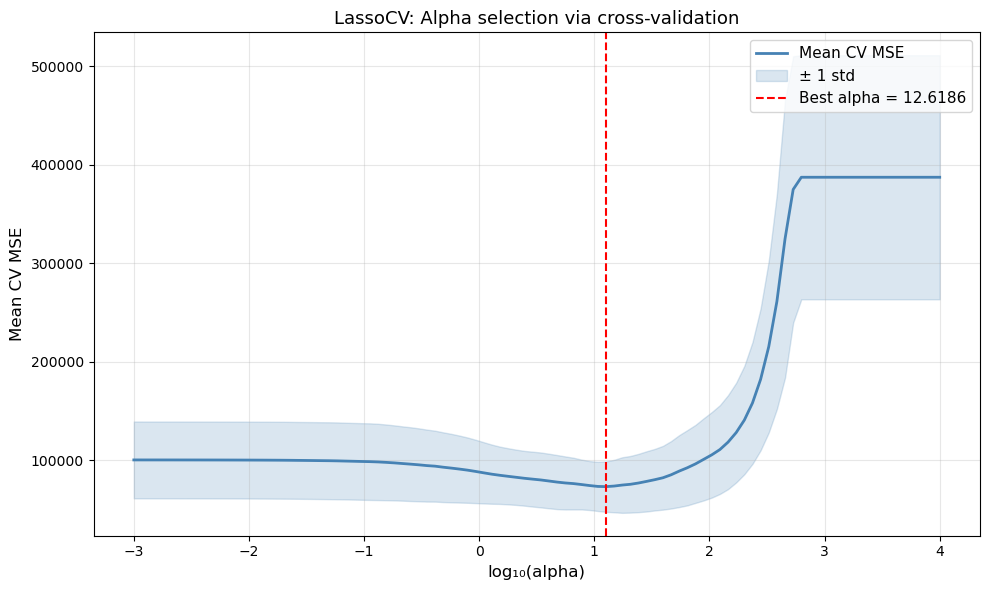

In [78]:
# Graph # the best alpha

alphas     = lasso_cv.alphas_
mean_mse   = lasso_cv.mse_path_.mean(axis=1)
std_mse    = lasso_cv.mse_path_.std(axis=1)
best_alpha = lasso_cv.alpha_

plt.figure(figsize=(10, 6))

# Mean CV MSE line
plt.plot(np.log10(alphas), mean_mse, color='steelblue', linewidth=2, label='Mean CV MSE')

# ± 1 std band
plt.fill_between(
    np.log10(alphas),
    mean_mse - std_mse,
    mean_mse + std_mse,
    alpha=0.2,
    color='steelblue',
    label='± 1 std'
)

# Best alpha vertical line
plt.axvline(
    np.log10(best_alpha),
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f'Best alpha = {best_alpha:.4f}'
)

plt.xlabel('log₁₀(alpha)', fontsize=12)
plt.ylabel('Mean CV MSE', fontsize=12)
plt.title('LassoCV: Alpha selection via cross-validation', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [79]:
# ======================================================================
# 4. FIT FINAL LASSO WITH BEST ALPHA ON SCALED DATA
# ======================================================================
lasso_model = Lasso(alpha=lasso_cv.alpha_, random_state=42, max_iter=100000)
lasso_model.fit(X_train_scaled, Y_train)

lasso_predictions = lasso_model.predict(X_test_scaled)
train_predictions = lasso_model.predict(X_train_scaled)

r2_train = r2_score(Y_train, train_predictions)
rmse_train = np.sqrt(mean_squared_error(Y_train, train_predictions))

print(f"Train R² : {r2_train:.4f}")
print(f"Train RMSE: ${rmse_train:,.4f}")

Train R² : 0.8438
Train RMSE: $243.2257


## Run Lasso

In [80]:
# ======================================================================
# 5. LASSO — PERFORMANCE
# ======================================================================
n        = len(Y_test)
k        = (lasso_model.coef_ != 0).sum()  # number of survived features
r2       = r2_score(Y_test, lasso_predictions)
adj_r2   = 1 - (1 - r2) * (n - 1) / (n - k - 1)
print("\n======================================================================")
print("LASSO MODEL PERFORMANCE")
print("======================================================================")
print(f"R²   : {r2_score(Y_test, lasso_predictions):.4f}")
print(f"Adj. R²   : {adj_r2:.4f}")
print(f"RMSE : ${np.sqrt(mean_squared_error(Y_test, lasso_predictions)):,.2f}")
print(f"MAE  : ${mean_absolute_error(Y_test, lasso_predictions):,.2f}")


LASSO MODEL PERFORMANCE
R²   : 0.8912
Adj. R²   : 0.8391
RMSE : $224.11
MAE  : $174.31


In [81]:
# ======================================================================
# 6. LASSO — FEATURE IMPORTANCE
# ======================================================================
feature_names = X.columns.tolist()
coefficients  = lasso_model.coef_

df_coef = pd.DataFrame({
    'Feature'        : feature_names,
    'Coefficient'    : coefficients,
    'Absolute_Impact': np.abs(coefficients)
})

df_positive   = df_coef[df_coef['Coefficient'] > 0].sort_values('Absolute_Impact', ascending=False)
df_negative   = df_coef[df_coef['Coefficient'] < 0].sort_values('Absolute_Impact', ascending=False)
df_eliminated = df_coef[df_coef['Coefficient'] == 0]

print("\n======================================================================")
print("LASSO REGRESSION FEATURE IMPORTANCE (TARGET: MEDIAN GROSS RENT)")
print(f"Best Alpha: {lasso_cv.alpha_:.4f}")
print("======================================================================")

print("\n FEATURES DRIVING RENT UP (Positive Impact)")
print("-" * 65)
if not df_positive.empty:
    for _, row in df_positive.iterrows():
        print(f"{row['Feature']:<38} | +{row['Coefficient']:.6f}")
else:
    print("None")

print("\n FEATURES DRIVING RENT DOWN (Negative Impact)")
print("-" * 65)
if not df_negative.empty:
    for _, row in df_negative.iterrows():
        print(f"{row['Feature']:<38} | {row['Coefficient']:.6f}")
else:
    print("None")

print("\n FEATURES ELIMINATED BY LASSO (Zero Impact / Redundant)")
print("-" * 65)
if not df_eliminated.empty:
    print(", ".join(df_eliminated['Feature'].tolist()))
else:
    print("None")

print(f"\n  Total kept     : {(coefficients != 0).sum()} / {len(coefficients)}")
print(f"  Total eliminated: {(coefficients == 0).sum()} / {len(coefficients)}")
print("======================================================================")


LASSO REGRESSION FEATURE IMPORTANCE (TARGET: MEDIAN GROSS RENT)
Best Alpha: 12.6186

 FEATURES DRIVING RENT UP (Positive Impact)
-----------------------------------------------------------------
median_household_income                | +475.780834
built_2010_2019                        | +107.227607
built_1980_1989                        | +66.855122
vacancy_rate                           | +45.237417
borough_Manhattan                      | +40.125905
borough_Queens                         | +8.073252

 FEATURES DRIVING RENT DOWN (Negative Impact)
-----------------------------------------------------------------
borough_Staten_Island                  | -68.336507
built_1990_1999                        | -51.054290
rent_lt_10pct_income                   | -40.693954
homeownership_rate                     | -17.877237
built_2020_or_later                    | -7.130080

 FEATURES ELIMINATED BY LASSO (Zero Impact / Redundant)
--------------------------------------------------------------

## Multiple Linear Regression

In [82]:
# ======================================================================
# 8. OLS — STATSMODELS (p-values, confidence intervals)
# ======================================================================
survived_mask     = lasso_model.coef_ != 0
survived_features = X.columns[survived_mask].tolist()

print(f"\nSurvived features ({len(survived_features)}): {survived_features}")

# Convert back to DataFrame using original column names, then filter to survived only
X_train_ols = pd.DataFrame(X_train, columns=X.columns)[survived_features]
X_test_ols  = pd.DataFrame(X_test,  columns=X.columns)[survived_features]

X_train_ols_const = sm.add_constant(X_train_ols)

ols_model = sm.OLS(Y_train, X_train_ols_const).fit()
print(ols_model.summary())


Survived features (11): ['rent_lt_10pct_income', 'median_household_income', 'built_2020_or_later', 'built_2010_2019', 'built_1990_1999', 'built_1980_1989', 'vacancy_rate', 'homeownership_rate', 'borough_Manhattan', 'borough_Queens', 'borough_Staten_Island']
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.855
Model:                            OLS   Adj. R-squared:                  0.843
Method:                 Least Squares   F-statistic:                     68.73
Date:                Sun, 29 Mar 2026   Prob (F-statistic):           3.01e-48
Time:                        00:22:44   Log-Likelihood:                -962.48
No. Observations:                 140   AIC:                             1949.
Df Residuals:                     128   BIC:                             1984.
Df Model:                          11                                         
Covariance Type:            no

In [83]:
# ======================================================================
# 9. OLS — PERFORMANCE ON TEST SET
# ======================================================================
X_test_ols_const = sm.add_constant(X_test_ols, has_constant='add')
ols_predictions  = ols_model.predict(X_test_ols_const)

n      = len(Y_test)
k      = len(survived_features)
r2     = r2_score(Y_test, ols_predictions)
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)

print("\n======================================================================")
print("OLS MODEL PERFORMANCE (TEST SET)")
print("======================================================================")
print(f"R²        : {r2:.4f}")
print(f"Adj. R²   : {adj_r2:.4f}")
print(f"RMSE      : ${np.sqrt(mean_squared_error(Y_test, ols_predictions)):,.2f}")
print(f"MAE       : ${mean_absolute_error(Y_test, ols_predictions):,.2f}")
print("======================================================================")


OLS MODEL PERFORMANCE (TEST SET)
R²        : 0.8759
Adj. R²   : 0.8165
RMSE      : $239.38
MAE       : $181.55


In [84]:
# ======================================================================
# 10. OLS — CROSS VALIDATION
# ======================================================================
def adjusted_r2(y_true, y_pred):
    n  = len(y_true)
    k  = len(survived_features)
    r2 = r2_score(y_true, y_pred)
    return 1 - (1 - r2) * (n - 1) / (n - k - 1)

adj_r2_scorer = make_scorer(adjusted_r2)

cv_results = cross_validate(
    LinearRegression(),
    pd.DataFrame(X.values, columns=X.columns)[survived_features],
    Y,
    cv= 5,
    scoring={
        'r2'     : 'r2',
        'adj_r2' : adj_r2_scorer,
        'neg_mse': 'neg_mean_squared_error',
        'neg_mae': 'neg_mean_absolute_error'
    },
    return_train_score=True
)

rmse = np.sqrt(-cv_results['test_neg_mse'])
mae  = -cv_results['test_neg_mae']

print("\n======================================================================")
print("OLS CROSS-VALIDATION RESULTS (5-Fold)")
print("======================================================================")
print(f"R²      (mean): {cv_results['test_r2'].mean():.4f}  |  std: {cv_results['test_r2'].std():.4f}")
print(f"Adj. R² (mean): {cv_results['test_adj_r2'].mean():.4f}  |  std: {cv_results['test_adj_r2'].std():.4f}")
print(f"RMSE    (mean): ${rmse.mean():,.2f}  |  std: ${rmse.std():,.2f}")
print(f"MAE     (mean): ${mae.mean():,.2f}  |  std: ${mae.std():,.2f}")
print("======================================================================")


OLS CROSS-VALIDATION RESULTS (5-Fold)
R²      (mean): 0.6208  |  std: 0.2725
Adj. R² (mean): 0.4394  |  std: 0.4028
RMSE    (mean): $283.18  |  std: $38.98
MAE     (mean): $208.48  |  std: $39.97


## Outlier-Inducded Variance

In [85]:
residuals = Y_test - ols_predictions

# Basic stats
print(f"Residual mean  : {residuals.mean():,.2f}")
print(f"Residual std   : {residuals.std():,.2f}")
print(f"Max residual   : {residuals.max():,.2f}")
print(f"Min residual   : {residuals.min():,.2f}")

# How many are extreme (> 2 std from mean)?
threshold = 2 * residuals.std()
n_outliers = (np.abs(residuals) > threshold).sum()
print(f"\nOutliers (> 2 std): {n_outliers} / {len(residuals)} ({n_outliers/len(residuals)*100:.1f}%)")

Residual mean  : -5.58
Residual std   : 242.81
Max residual   : 570.34
Min residual   : -735.78

Outliers (> 2 std): 2 / 35 (5.7%)


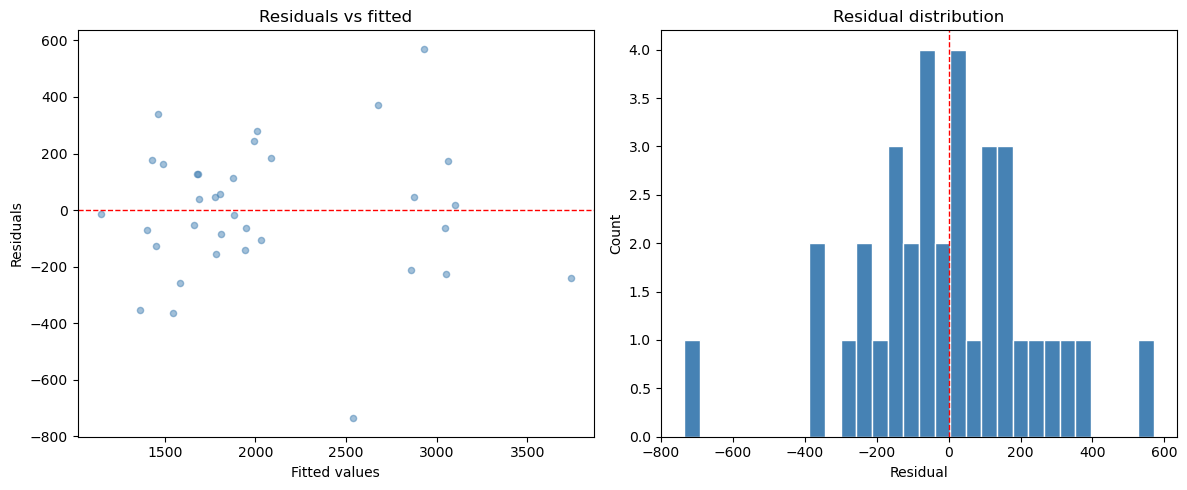

In [86]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Residuals vs fitted
axes[0].scatter(ols_predictions, residuals, alpha=0.5, color='steelblue', s=20)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs fitted')

# Residual distribution
axes[1].hist(residuals, bins=30, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual distribution')

plt.tight_layout()
plt.show()

In [87]:
# outlier_mask = np.abs(residuals) <= 2 * residuals.std()
# Y_test_clean        = Y_test[outlier_mask]
# ols_predictions_clean = ols_predictions[outlier_mask]

# # Option B — Winsorize (cap extremes rather than remove)
# from scipy.stats import mstats

# Y_winsorized = mstats.winsorize(Y, limits=[0.05, 0.05])  # cap top/bottom 5%

## Cook's Distance

Threshold (4/n): 0.0286
Influential observations: 10 / 140 (7.1%)


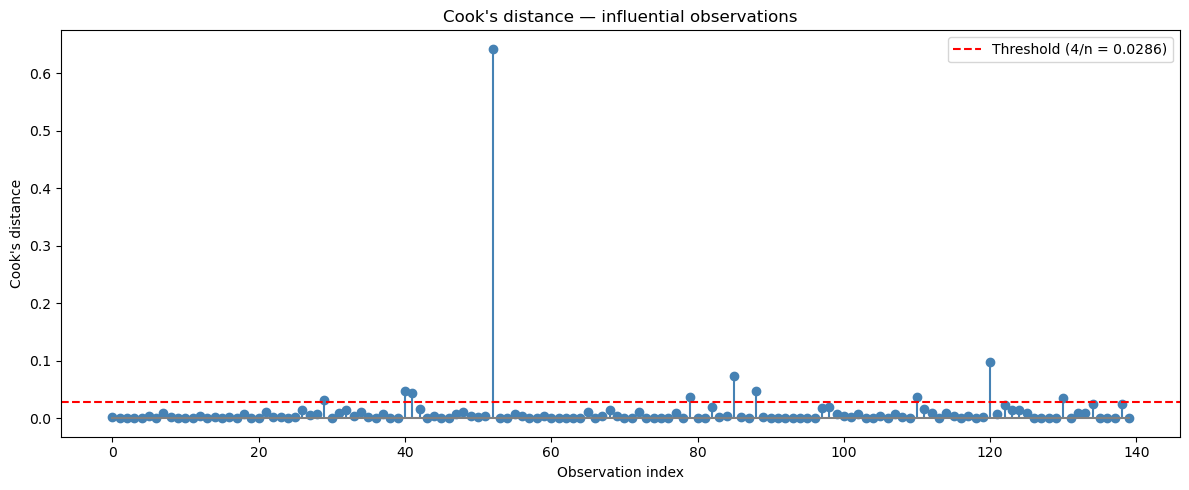

In [88]:
# Calculate Cook's distance from the fitted OLS model
influence  = OLSInfluence(ols_model)
cooks_d, _ = influence.cooks_distance

# Common threshold: 4 / n
n         = len(Y_train)
threshold = 4 / n

print(f"Threshold (4/n): {threshold:.4f}")
print(f"Influential observations: {(cooks_d > threshold).sum()} / {n} ({(cooks_d > threshold).sum()/n*100:.1f}%)")

# Plot
plt.figure(figsize=(12, 5))
plt.stem(
    range(len(cooks_d)),
    cooks_d,
    markerfmt='o',
    linefmt='steelblue',
    basefmt='gray'
)
plt.axhline(threshold, color='red', linestyle='--', linewidth=1.5, label=f'Threshold (4/n = {threshold:.4f})')
plt.xlabel('Observation index')
plt.ylabel("Cook's distance")
plt.title("Cook's distance — influential observations")
plt.legend()
plt.tight_layout()
plt.show()

## Identify influential observations 

In [89]:
# ======================================================================
# Identify influential observations
# ======================================================================
influential_idx   = np.where(cooks_d > threshold)[0]
train_predictions = ols_model.predict(X_train_ols_const)
train_residuals   = Y_train - train_predictions

print("\nInfluential observations:")
print("-" * 60)
for idx in influential_idx:
    print(f"Index {idx}:")
    print(f"  Cook's distance : {cooks_d[idx]:.4f}")
    print(f"  Actual rent     : ${Y_train[idx]:,.2f}")
    print(f"  Predicted rent  : ${train_predictions.iloc[idx]:,.2f}")
    print(f"  Residual        : ${train_residuals.iloc[idx]:,.2f}")
    print()


Influential observations:
------------------------------------------------------------
Index 29:
  Cook's distance : 0.0317
  Actual rent     : $3,501.00
  Predicted rent  : $3,849.04
  Residual        : $-348.04

Index 40:
  Cook's distance : 0.0476
  Actual rent     : $3,361.00
  Predicted rent  : $2,872.10
  Residual        : $488.90

Index 41:
  Cook's distance : 0.0437
  Actual rent     : $3,069.00
  Predicted rent  : $2,227.80
  Residual        : $841.20

Index 52:
  Cook's distance : 0.6423
  Actual rent     : $2,908.00
  Predicted rent  : $3,260.09
  Residual        : $-352.09

Index 79:
  Cook's distance : 0.0376
  Actual rent     : $3,501.00
  Predicted rent  : $3,908.05
  Residual        : $-407.05

Index 85:
  Cook's distance : 0.0743
  Actual rent     : $3,189.00
  Predicted rent  : $2,362.84
  Residual        : $826.16

Index 88:
  Cook's distance : 0.0474
  Actual rent     : $3,501.00
  Predicted rent  : $3,824.68
  Residual        : $-323.68

Index 110:
  Cook's distan

## What are deleted?

In [90]:
train_df = pd.DataFrame(X_train, columns=X.columns)
train_df['Y_train'] = Y_train
train_df['zip'] = df_merged.loc[df_model.index[:len(X_train)], 'zip'].values
train_df['borough'] = df_merged.loc[df_model.index[:len(X_train)], 'borough'].values

print("\nInfluential zipcodes summary:")
print("-" * 60)
for idx in influential_idx:
    print(f"  Zip: {train_df['zip'].iloc[idx]}  |  Borough: {train_df['borough'].iloc[idx]}  |  Actual rent: ${Y_train[idx]:,.2f}  |  Cook's D: {cooks_d[idx]:.4f}")


Influential zipcodes summary:
------------------------------------------------------------
  Zip: 10033  |  Borough: Manhattan  |  Actual rent: $3,501.00  |  Cook's D: 0.0317
  Zip: 10075  |  Borough: Manhattan  |  Actual rent: $3,361.00  |  Cook's D: 0.0476
  Zip: 10128  |  Borough: Manhattan  |  Actual rent: $3,069.00  |  Cook's D: 0.0437
  Zip: 10309  |  Borough: Staten Island  |  Actual rent: $2,908.00  |  Cook's D: 0.6423
  Zip: 10474  |  Borough: Bronx  |  Actual rent: $3,501.00  |  Cook's D: 0.0376
  Zip: 11105  |  Borough: Queens  |  Actual rent: $3,189.00  |  Cook's D: 0.0743
  Zip: 11203  |  Borough: Brooklyn  |  Actual rent: $3,501.00  |  Cook's D: 0.0474
  Zip: 11225  |  Borough: Brooklyn  |  Actual rent: $2,659.00  |  Cook's D: 0.0362
  Zip: 11236  |  Borough: Brooklyn  |  Actual rent: $3,327.00  |  Cook's D: 0.0973
  Zip: 11360  |  Borough: Queens  |  Actual rent: $3,358.00  |  Cook's D: 0.0346


## Remove and refit  

In [91]:
non_influential_mask = cooks_d <= threshold

X_train_clean       = X_train_ols[non_influential_mask]
Y_train_clean       = Y_train[non_influential_mask]

print(f"Observations removed : {(~non_influential_mask).sum()}")
print(f"Observations kept    : {non_influential_mask.sum()} / {len(Y_train)}")

X_train_clean_const = sm.add_constant(X_train_clean)
ols_model_clean     = sm.OLS(Y_train_clean, X_train_clean_const).fit()

print(ols_model_clean.summary())

Observations removed : 10
Observations kept    : 130 / 140
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.890
Model:                            OLS   Adj. R-squared:                  0.880
Method:                 Least Squares   F-statistic:                     86.72
Date:                Sun, 29 Mar 2026   Prob (F-statistic):           3.78e-51
Time:                        00:22:44   Log-Likelihood:                -857.26
No. Observations:                 130   AIC:                             1739.
Df Residuals:                     118   BIC:                             1773.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------

In [92]:
X_test_ols_const  = sm.add_constant(X_test_ols, has_constant='add')
ols_predictions_clean = ols_model_clean.predict(X_test_ols_const)

n      = len(Y_test)
k      = len(survived_features)
r2     = r2_score(Y_test, ols_predictions_clean)
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)

print("\n======================================================================")
print("OLS MODEL PERFORMANCE AFTER COOK'S DISTANCE REMOVAL (TEST SET)")
print("======================================================================")
print(f"R² after  : {r2:.4f}")
print(f"Adj. R² before : {ols_model.rsquared_adj:.4f}")
print(f"Adj. R² after  : {adj_r2:.4f}")
print(f"RMSE           : ${np.sqrt(mean_squared_error(Y_test, ols_predictions_clean)):,.2f}")
print(f"MAE            : ${mean_absolute_error(Y_test, ols_predictions_clean):,.2f}")
print("======================================================================")


OLS MODEL PERFORMANCE AFTER COOK'S DISTANCE REMOVAL (TEST SET)
R² after  : 0.8682
Adj. R² before : 0.8428
Adj. R² after  : 0.8052
RMSE           : $246.65
MAE            : $177.56


In [93]:
## CV

# Use cleaned training data (influential rows removed)
X_clean_ols = pd.DataFrame(X_train, columns=X.columns)[survived_features][non_influential_mask]
Y_clean     = Y_train[non_influential_mask]

cv_results_clean = cross_validate(
    LinearRegression(),
    X_clean_ols,
    Y_clean,
    cv=5,
    scoring={
        'r2'     : 'r2',
        'adj_r2' : adj_r2_scorer,
        'neg_mse': 'neg_mean_squared_error',
        'neg_mae': 'neg_mean_absolute_error'
    },
    return_train_score=True
)

rmse = np.sqrt(-cv_results_clean['test_neg_mse'])
mae  = -cv_results_clean['test_neg_mae']

print("\n======================================================================")
print("OLS CV RESULTS AFTER COOK'S DISTANCE REMOVAL (5-Fold)")
print("======================================================================")
print(f"R²      (mean): {cv_results_clean['test_r2'].mean():.4f}  |  std: {cv_results_clean['test_r2'].std():.4f}")
print(f"Adj. R² (mean): {cv_results_clean['test_adj_r2'].mean():.4f}  |  std: {cv_results_clean['test_adj_r2'].std():.4f}")
print(f"RMSE    (mean): ${rmse.mean():,.2f}  |  std: ${rmse.std():,.2f}")
print(f"MAE     (mean): ${mae.mean():,.2f}  |  std: ${mae.std():,.2f}")
print("======================================================================")


OLS CV RESULTS AFTER COOK'S DISTANCE REMOVAL (5-Fold)
R²      (mean): 0.8613  |  std: 0.0494
Adj. R² (mean): 0.7523  |  std: 0.0883
RMSE    (mean): $188.82  |  std: $32.43
MAE     (mean): $150.15  |  std: $25.00


In [94]:
# Features associated:
significant_features = [
    feat for feat, pval in zip(survived_features, ols_model_clean.pvalues[1:])
    if pval < 0.05
]

print(f"\n3. SIGNIFICANT IN OLS p<0.05 ({len(significant_features)} features):")
print("-" * 40)
for i, feat in enumerate(significant_features, 1):
    print(f"  {i:>2}. {feat}")


3. SIGNIFICANT IN OLS p<0.05 (9 features):
----------------------------------------
   1. rent_lt_10pct_income
   2. median_household_income
   3. built_2020_or_later
   4. built_2010_2019
   5. built_1990_1999
   6. built_1980_1989
   7. homeownership_rate
   8. borough_Queens
   9. borough_Staten_Island


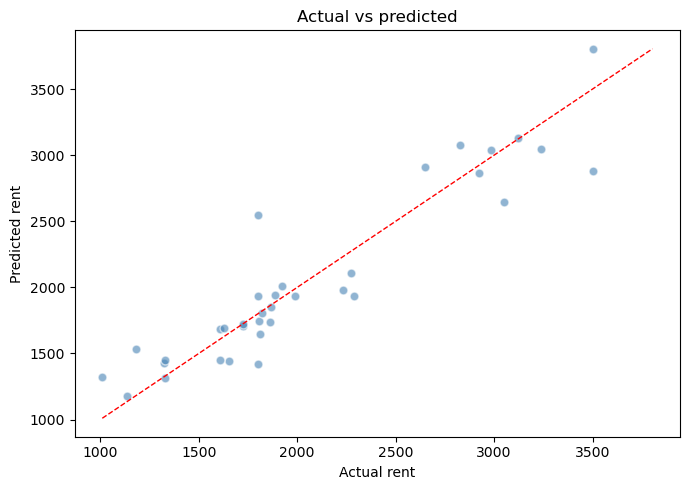

In [95]:
plt.figure(figsize=(7, 5))
plt.scatter(Y_test, ols_predictions_clean, alpha=0.6,
            color='steelblue', s=40, edgecolors='white')
min_val = min(Y_test.min(), ols_predictions_clean.min())
max_val = max(Y_test.max(), ols_predictions_clean.max())
plt.plot([min_val, max_val], [min_val, max_val],
         color='red', linestyle='--', linewidth=1)
plt.title('Actual vs predicted')
plt.xlabel('Actual rent')
plt.ylabel('Predicted rent')
plt.tight_layout()
plt.show()

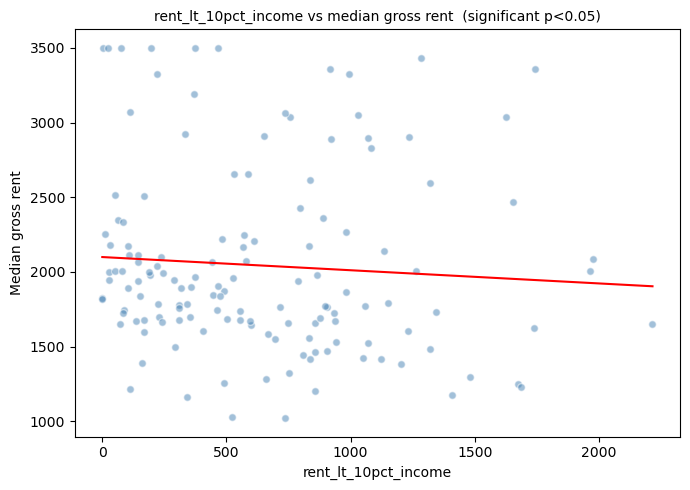

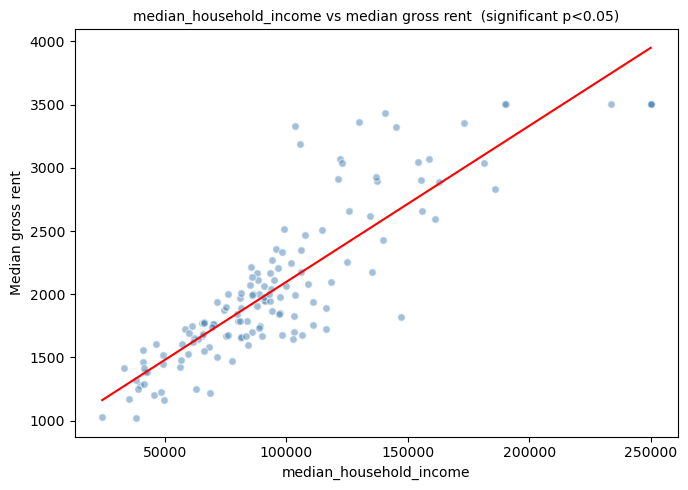

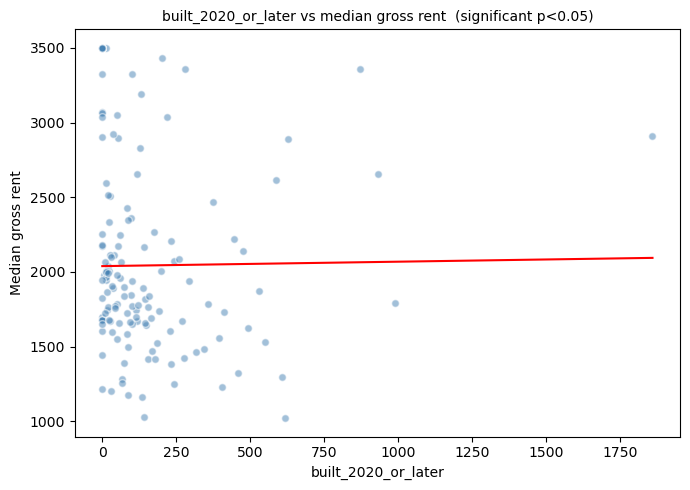

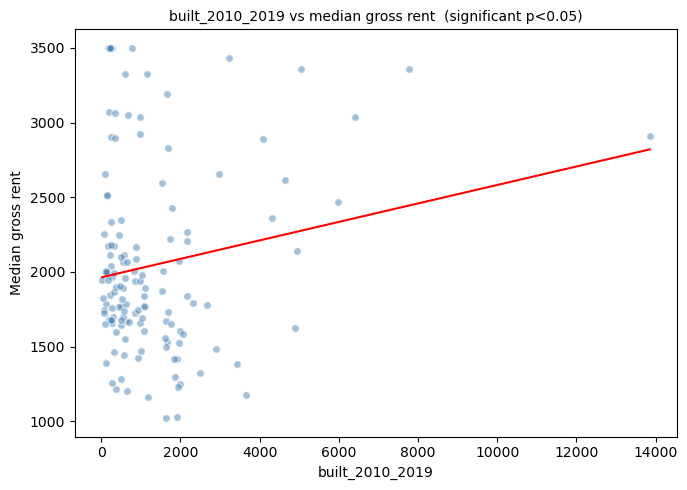

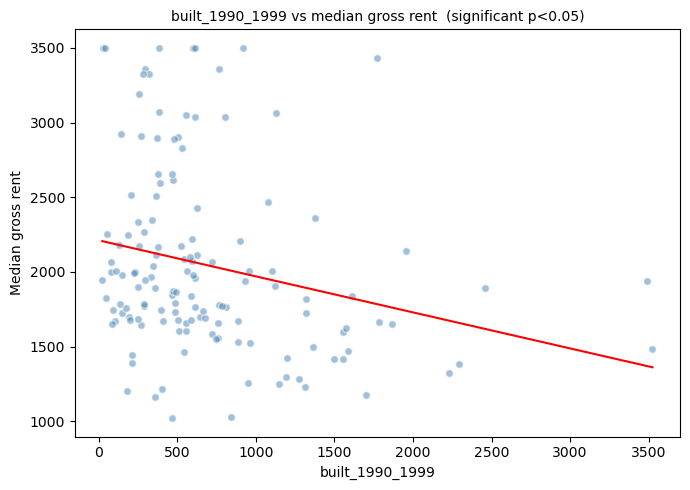

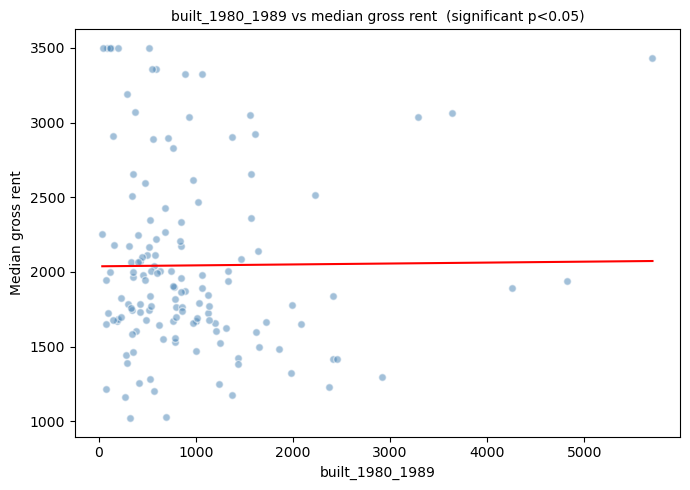

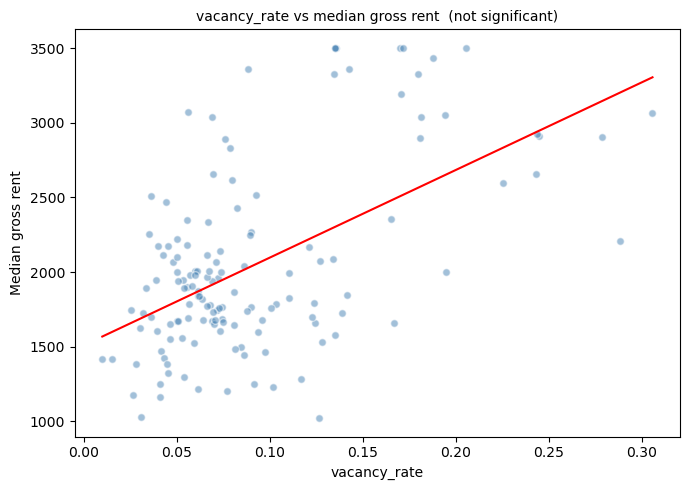

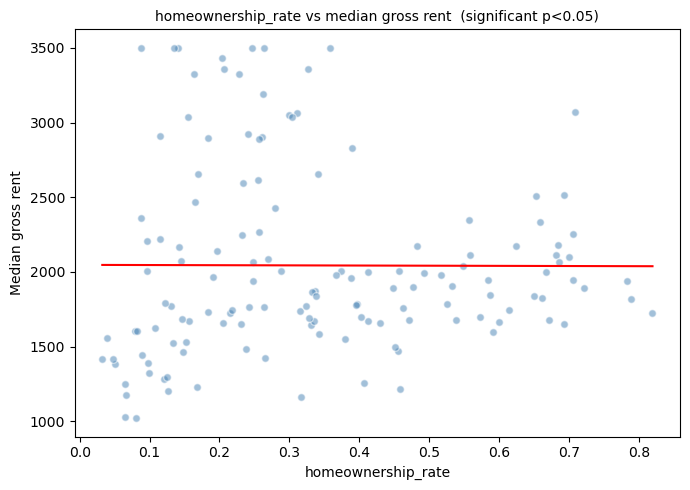

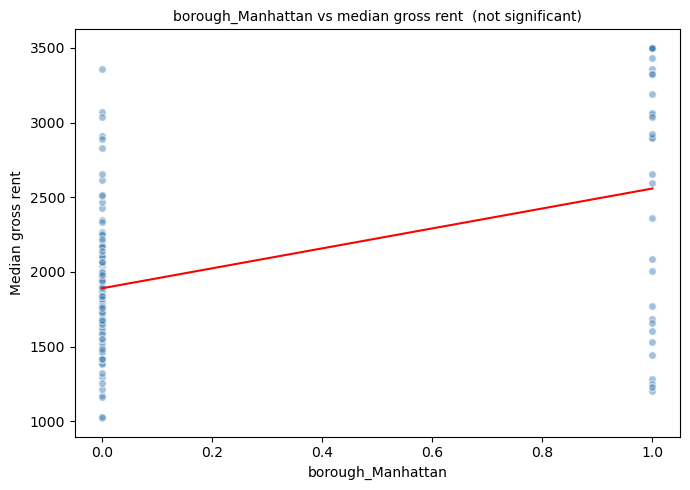

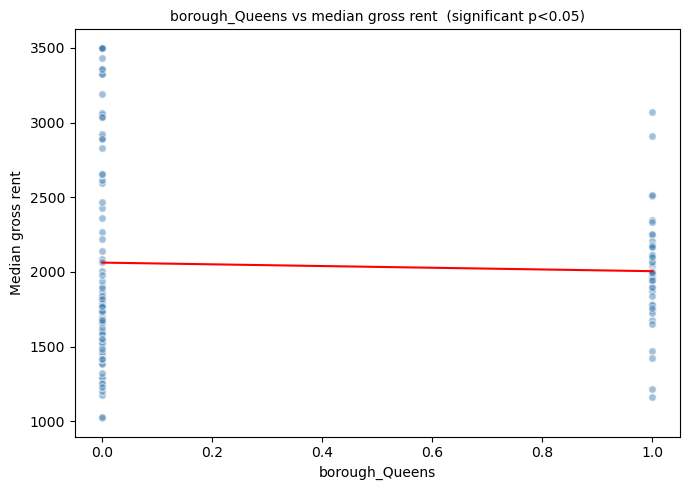

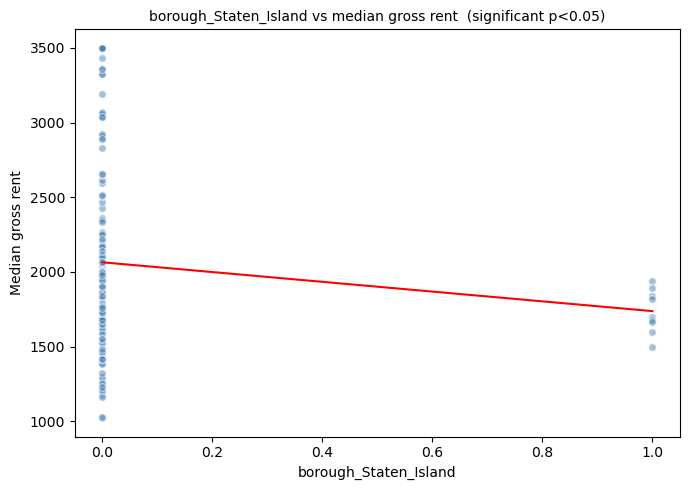

In [96]:
# ======================================================================
# 2. Each variable vs median gross rent
# ======================================================================
for feature in survived_features:
    x_vals = X_train_ols[feature]
    y_vals = Y_train

    m, b   = np.polyfit(x_vals, y_vals, 1)
    x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
    pval   = ols_model_clean.pvalues[feature]
    sig    = '(significant p<0.05)' if pval < 0.05 else '(not significant)'

    plt.figure(figsize=(7, 5))
    plt.scatter(x_vals, y_vals, alpha=0.5, color='steelblue',
                s=30, edgecolors='white')
    plt.plot(x_line, m * x_line + b, color='red', linewidth=1.5)
    plt.title(f'{feature} vs median gross rent  {sig}', fontsize=10)
    plt.xlabel(feature)
    plt.ylabel('Median gross rent')
    plt.tight_layout()
    plt.show()

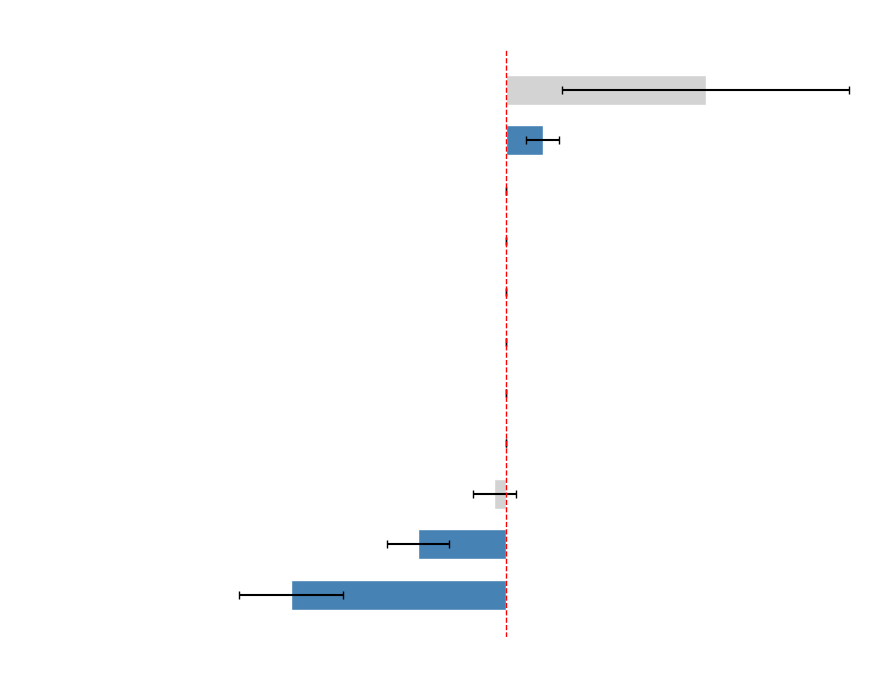

In [97]:
import matplotlib.pyplot as plt
import numpy as np

coefs  = ols_model_clean.params[1:]    # exclude const
errors = ols_model_clean.bse[1:]       # standard errors (error bars)
pvals  = ols_model_clean.pvalues[1:]

# Sort by coefficient value
sorted_idx = coefs.argsort()
coefs      = coefs.iloc[sorted_idx]
errors     = errors.iloc[sorted_idx]
pvals      = pvals.iloc[sorted_idx]
colors     = ['steelblue' if p < 0.05 else 'lightgray' for p in pvals]

bg_color   = '#06363b'
text_color = 'white'

#plt.figure(figsize=(9, len(coefs) * 0.5 + 2))
# plt.figure(figsize=(9, len(coefs) * 0.4 + 2))
plt.figure(figsize=(9, 7))

# plt.gcf().set_facecolor(bg_color)
# plt.gca().set_facecolor(bg_color)

plt.gca().set_facecolor('none')

#PPT background color: #06363b
plt.barh(coefs.index, coefs.values, xerr=errors.values,
         color=colors, edgecolor='white', capsize=3, height=0.6)
plt.axvline(0, color='red', linestyle='--', linewidth=1)

plt.title('OLS regression — coefficient plot\n(blue = significant p<0.05, gray = not significant)',
          fontsize=11, color = text_color)
plt.xlabel('Coefficient value (effect on median gross rent)', color = text_color)

plt.gca().tick_params(colors=text_color)
for spine in plt.gca().spines.values():
    spine.set_edgecolor(text_color)

plt.tight_layout()
#plt.savefig("Coeff plot for the best fit.png", dpi = 400, transparent = True)
plt.show()

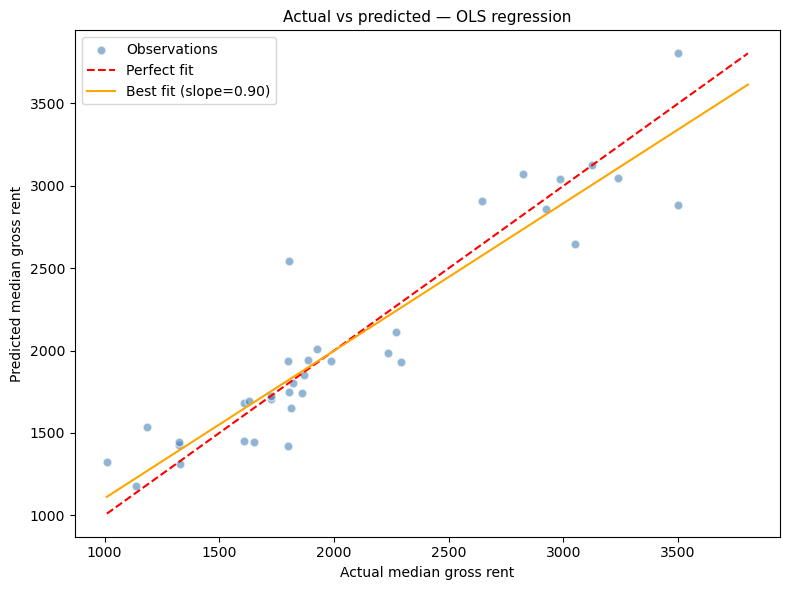

In [98]:
plt.figure(figsize=(8, 6))

# Scatter of actual vs predicted
plt.scatter(Y_test, ols_predictions_clean, alpha=0.6,
            color='steelblue', s=40, edgecolors='white', label='Observations')

# Perfect prediction line (45 degree)
min_val = min(Y_test.min(), ols_predictions_clean.min())
max_val = max(Y_test.max(), ols_predictions_clean.max())
plt.plot([min_val, max_val], [min_val, max_val],
         color='red', linestyle='--', linewidth=1.5, label='Perfect fit')

# Line of best fit through the predicted points
m, b   = np.polyfit(Y_test, ols_predictions_clean, 1)
x_line = np.linspace(min_val, max_val, 100)
plt.plot(x_line, m * x_line + b,
         color='orange', linewidth=1.5, label=f'Best fit (slope={m:.2f})')

plt.title('Actual vs predicted — OLS regression', fontsize=11)
plt.xlabel('Actual median gross rent')
plt.ylabel('Predicted median gross rent')
plt.legend()
plt.tight_layout()
plt.show()

# Intensity Variable


In [99]:
df_merged

# stabilization_share = indicator of rent intensity

,Unnamed: 0,geoid,zip,borough,rent_burden_total_renter_households,rent_lt_10pct_income,rent_10_to_14_9pct_income,rent_15_to_19_9pct_income,rent_20_to_24_9pct_income,rent_25_to_29_9pct_income,rent_30_to_34_9pct_income,rent_35_to_39_9pct_income,rent_40_to_49_9pct_income,rent_50pct_or_more_income,rent_not_computed,housing_units_total,median_gross_rent,median_household_income,occupancy_total_units,occupied_units,vacant_units,tenure_total_occupied_units,owner_occupied_units,renter_occupied_units,total_population,year_built_total_units,built_2020_or_later,built_2010_2019,built_2000_2009,built_1990_1999,built_1980_1989,built_1970_1979,built_1960_1969,built_1950_1959,built_1940_1949,built_1939_or_earlier,zipcode,total_units,stabilized_units,stabilized_buildings,total_buildings,stabilization_share,vacancy_rate,homeownership_rate,new_construction_share,renter_density,pre_war_share,borough_Brooklyn,borough_Manhattan,borough_Queens,borough_Staten_Island
0,31,86000US10001,10001,Manhattan,11939.0,917.0,1502.0,1801.0,1484.0,1181.0,1074.0,546.0,892.0,2137.0,405.0,18356.0,3361.0,129852.0,18356.0,15737.0,2619.0,15737.0,3798.0,11939.0,30511.0,18356.0,280.0,5049.0,2404.0,296.0,590.0,423.0,3290.0,553.0,508.0,4963.0,10001,22303.0,12310.0,127,356,0.551944,0.142678,0.206908,0.290314,0.650414,0.270375,0.0,1.0,0.0,0.0
1,32,86000US10002,10002,Manhattan,29732.0,1688.0,2438.0,2857.0,3466.0,3197.0,3752.0,1338.0,2076.0,7758.0,1162.0,40696.0,1229.0,48386.0,40696.0,36556.0,4140.0,36556.0,6824.0,29732.0,76873.0,40696.0,403.0,1940.0,1590.0,1313.0,2373.0,3566.0,4822.0,6003.0,2838.0,15848.0,10002,36840.0,14431.0,601,1180,0.391721,0.101730,0.167682,0.057573,0.730588,0.389424,0.0,1.0,0.0,0.0
2,33,86000US10003,10003,Manhattan,15410.0,1031.0,2255.0,1722.0,1455.0,1355.0,1147.0,1171.0,1148.0,3480.0,646.0,30413.0,3049.0,154262.0,30413.0,24503.0,5910.0,24503.0,9093.0,15410.0,53560.0,30413.0,50.0,683.0,989.0,558.0,1555.0,1560.0,4611.0,2456.0,1425.0,16526.0,10003,33576.0,18652.0,602,1479,0.555516,0.194325,0.298984,0.024102,0.506691,0.543386,0.0,1.0,0.0,0.0
3,34,86000US10004,10004,Manhattan,1060.0,21.0,119.0,255.0,84.0,39.0,128.0,72.0,136.0,206.0,0.0,2247.0,3501.0,250001.0,2247.0,1865.0,382.0,1865.0,805.0,1060.0,3711.0,2247.0,0.0,221.0,421.0,44.0,115.0,18.0,33.0,5.0,6.0,1384.0,10004,4492.0,1248.0,5,37,0.277827,0.170004,0.358255,0.098353,0.471740,0.615932,0.0,1.0,0.0,0.0
4,35,86000US10005,10005,Manhattan,4323.0,77.0,515.0,461.0,664.0,559.0,364.0,188.0,331.0,1164.0,0.0,6606.0,3501.0,190233.0,6606.0,5248.0,1358.0,5248.0,925.0,4323.0,9439.0,6606.0,0.0,161.0,841.0,601.0,125.0,515.0,393.0,339.0,218.0,3413.0,10005,6871.0,2923.0,8,25,0.425411,0.205571,0.140024,0.024372,0.654405,0.516652,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,253,86000US11691,11691,Queens,16665.0,1049.0,1126.0,915.0,1993.0,1893.0,1332.0,1320.0,1426.0,4702.0,909.0,24072.0,1425.0,56135.0,24072.0,23039.0,1033.0,23039.0,6374.0,16665.0,69359.0,24072.0,276.0,925.0,2531.0,1196.0,1430.0,4074.0,3541.0,4225.0,1461.0,4413.0,11691,24882.0,9036.0,156,5608,0.363154,0.042913,0.264789,0.049892,0.692298,0.183325,0.0,0.0,1.0,0.0
174,254,86000US11692,11692,Queens,5400.0,342.0,471.0,405.0,408.0,251.0,426.0,560.0,412.0,1734.0,391.0,8415.0,1161.0,49720.0,8415.0,8070.0,345.0,8070.0,2670.0,5400.0,22734.0,8415.0,135.0,1175.0,1307.0,361.0,275.0,1368.0,1223.0,1205.0,382.0,984.0,11692,8348.0,83.0,16,2083,0.009943,0.040998,0.317291,0.155674,0.641711,0.116934,0.0,0.0,1.0,0.0
175,255,86000US11693,11693,Queens,2847.0,112.0,238.0,240.0,301.0,375.0,220.0,87.0,171.0,907.0,196.0,5922.0,1216.0,68449.0,5922.0,5559.0,363.0,5559.0,2712.0,2847.0,13244.0,5922.0,0.0,377.0,811.0,406.0,71.0,495.0,1128.0,997.0,520.0,1117.0,11693,4727.0,340.0,48,1526,0.071927,0.061297,0.457953,0.063661,0.480750,0.188619,0.0,0.0,1.0,0.0
176,256,86000US11694,11694,Queens,3963.0,310.0,263.0,685.0

In [100]:
# X['stabilization_share'] = df_merged['stabilization_share'] 
# X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.20, random_state=42)

In [101]:
# add the stabilization share as a variable

survived_features_new = survived_features + ['stabilization_share']

# Rebuild train/test OLS dataframes
X_train_ols_new = pd.DataFrame(X_train, columns=X.columns)[survived_features_new]
X_test_ols_new  = pd.DataFrame(X_test,  columns=X.columns)[survived_features_new]

# Remove influential observations
X_train_ols_new_clean = X_train_ols_new[non_influential_mask]
# X_train_ols_new_clean = X_train_ols_new.iloc[non_influential_mask.values]

# Refit OLS
X_train_ols_new_const = sm.add_constant(X_train_ols_new_clean)
ols_model_new         = sm.OLS(Y_train_clean, X_train_ols_new_const).fit()

print(ols_model_new.summary())

# Compare the two models
print("\n======================================================================")
print("MODEL COMPARISON — WITH vs WITHOUT stabilization_share")
print("======================================================================")
print(f"{'Metric':<25} {'Without':>10} {'With':>10}")
print("-" * 47)
print(f"{'Adj. R²':<25} {ols_model_clean.rsquared_adj:>10.4f} {ols_model_new.rsquared_adj:>10.4f}")
print(f"{'AIC':<25} {ols_model_clean.aic:>10.2f} {ols_model_new.aic:>10.2f}")
print(f"{'BIC':<25} {ols_model_clean.bic:>10.2f} {ols_model_new.bic:>10.2f}")
print(f"{'No. observations':<25} {int(ols_model_clean.nobs):>10} {int(ols_model_new.nobs):>10}")
print("======================================================================")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.890
Model:                            OLS   Adj. R-squared:                  0.879
Method:                 Least Squares   F-statistic:                     78.87
Date:                Sun, 29 Mar 2026   Prob (F-statistic):           3.48e-50
Time:                        00:22:45   Log-Likelihood:                -857.22
No. Observations:                 130   AIC:                             1740.
Df Residuals:                     117   BIC:                             1778.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [102]:
X_test_ols_new_const = sm.add_constant(X_test_ols_new, has_constant='add')
ols_predictions_new  = ols_model_new.predict(X_test_ols_new_const)

n      = len(Y_test)
k      = len(survived_features_new)   # updated feature count
r2     = r2_score(Y_test, ols_predictions_new)
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)

print("\n======================================================================")
print("OLS MODEL PERFORMANCE WITH stabilization_share (TEST SET)")
print("======================================================================")
print(f"R² (with stabilization_share)    : {r2:.4f}")
print(f"Adj. R² (without stabilization_share) : {ols_model_clean.rsquared_adj:.4f}")
print(f"Adj. R² (with stabilization_share)    : {adj_r2:.4f}")
print(f"RMSE : ${np.sqrt(mean_squared_error(Y_test, ols_predictions_new)):,.2f}")
print(f"MAE  : ${mean_absolute_error(Y_test, ols_predictions_new):,.2f}")
print("======================================================================")


OLS MODEL PERFORMANCE WITH stabilization_share (TEST SET)
R² (with stabilization_share)    : 0.8672
Adj. R² (without stabilization_share) : 0.8796
Adj. R² (with stabilization_share)    : 0.7948
RMSE : $247.58
MAE  : $178.27


In [103]:
X_clean_ols_new = pd.DataFrame(X_train, columns=X.columns)[survived_features_new][non_influential_mask].apply(pd.to_numeric, errors='coerce')

cv_results_new = cross_validate(
    LinearRegression(),
    X_clean_ols_new,
    Y_clean,                    # same cleaned Y_train
    cv=5,
    scoring={
        'r2'     : 'r2',
        'adj_r2' : adj_r2_scorer,
        'neg_mse': 'neg_mean_squared_error',
        'neg_mae': 'neg_mean_absolute_error'
    },
    return_train_score=True
)

rmse_new = np.sqrt(-cv_results_new['test_neg_mse'])
mae_new  = -cv_results_new['test_neg_mae']

print("\n======================================================================")
print("CV COMPARISON — WITHOUT vs WITH stabilization_share")
print("======================================================================")
print(f"{'Metric':<20} {'Without':>10} {'With':>10}")
print("-" * 42)
print(f"{'R² (mean)':<20} {cv_results_clean['test_r2'].mean():>10.4f} {cv_results_new['test_r2'].mean():>10.4f}")
print(f"{'Adj. R² (mean)':<20} {cv_results_clean['test_adj_r2'].mean():>10.4f} {cv_results_new['test_adj_r2'].mean():>10.4f}")
print(f"{'RMSE (mean)':<20} ${np.sqrt(-cv_results_clean['test_neg_mse']).mean():>9,.2f} ${rmse_new.mean():>9,.2f}")
print(f"{'MAE (mean)':<20} ${(-cv_results_clean['test_neg_mae']).mean():>9,.2f} ${(-cv_results_new['test_neg_mae']).mean():>9,.2f}")
print("======================================================================")


CV COMPARISON — WITHOUT vs WITH stabilization_share
Metric                  Without       With
------------------------------------------
R² (mean)                0.8613     0.8599
Adj. R² (mean)           0.7523     0.7498
RMSE (mean)          $   188.82 $   189.94
MAE (mean)           $   150.15 $   151.65


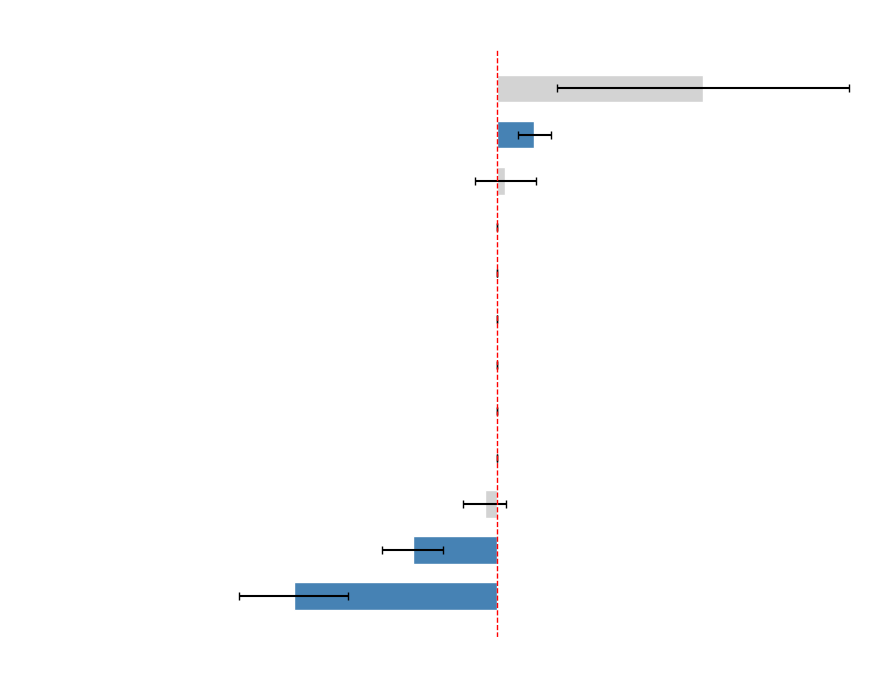

In [104]:
import matplotlib.pyplot as plt
import numpy as np

coefs  = ols_model_new.params[1:]    # exclude const
errors = ols_model_new.bse[1:]       # standard errors (error bars)
pvals  = ols_model_new.pvalues[1:]

# Sort by coefficient value
sorted_idx = coefs.argsort()
coefs      = coefs.iloc[sorted_idx]
errors     = errors.iloc[sorted_idx]
pvals      = pvals.iloc[sorted_idx]
colors     = ['steelblue' if p < 0.05 else 'lightgray' for p in pvals]

bg_color   = '#06363b'
text_color = 'white'

#plt.figure(figsize=(9, len(coefs) * 0.5 + 2))
#plt.figure(figsize=(9, len(coefs) * 0.4 + 1.5))
plt.figure(figsize=(9, 7))

plt.gca().set_facecolor('none')

plt.barh(coefs.index, coefs.values, xerr=errors.values,
         color=colors, edgecolor='white', capsize=3, height=0.6)
plt.axvline(0, color='red', linestyle='--', linewidth=1)

plt.title('OLS regression — coefficient plot\n(blue = significant p<0.05, gray = not significant)',
          fontsize=11, color = text_color)
plt.xlabel('Coefficient value (effect on median gross rent)', color = text_color)

plt.gca().tick_params(colors=text_color)
for spine in plt.gca().spines.values():
    spine.set_edgecolor(text_color)

plt.tight_layout()
# plt.savefig("Coeff Plot with Intensity Variable.png", dpi = 400, transparent = True)
plt.show()

## Graph

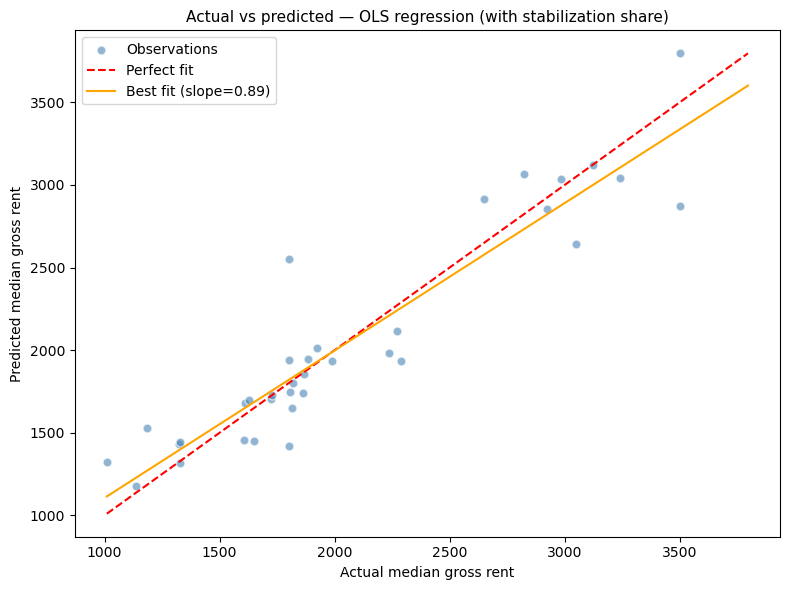

In [105]:
plt.figure(figsize=(8, 6))

# Scatter of actual vs predicted
plt.scatter(Y_test, ols_predictions_new, alpha=0.6,
            color='steelblue', s=40, edgecolors='white', label='Observations')

# Perfect prediction line (45 degree)
min_val = min(Y_test.min(), ols_predictions_new.min())
max_val = max(Y_test.max(), ols_predictions_new.max())
plt.plot([min_val, max_val], [min_val, max_val],
         color='red', linestyle='--', linewidth=1.5, label='Perfect fit')

# Line of best fit through the predicted points
m, b   = np.polyfit(Y_test, ols_predictions_new, 1)
x_line = np.linspace(min_val, max_val, 100)
plt.plot(x_line, m * x_line + b,
         color='orange', linewidth=1.5, label=f'Best fit (slope={m:.2f})')

plt.title('Actual vs predicted — OLS regression (with stabilization share)', fontsize=11)
plt.xlabel('Actual median gross rent')
plt.ylabel('Predicted median gross rent')
plt.legend()
plt.tight_layout()
plt.show()

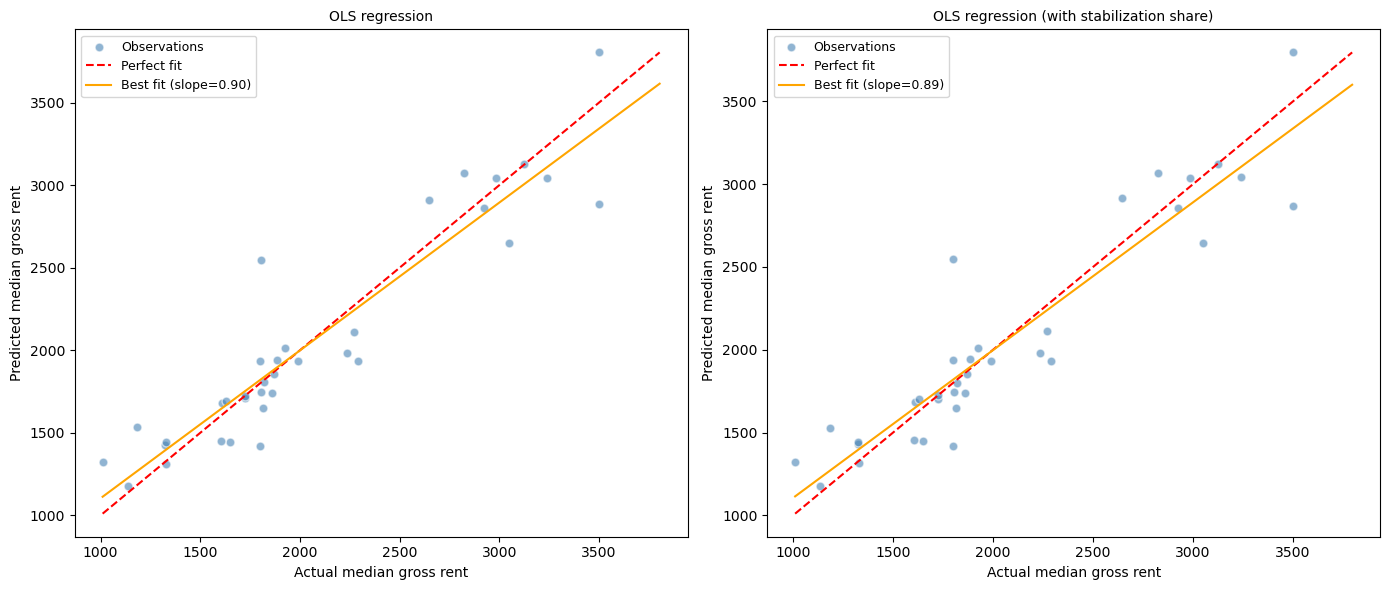

In [106]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ols_predictions_clean = np.array(ols_predictions_clean)
ols_predictions_new   = np.array(ols_predictions_new)

for ax, preds, title in zip(
    axes,
    [ols_predictions_clean, ols_predictions_new],
    ['OLS regression', 'OLS regression (with stabilization share)']
):
    ax.scatter(Y_test, preds, alpha=0.6, color='steelblue',
               s=40, edgecolors='white', label='Observations')

    min_val = min(Y_test.min(), preds.min())
    max_val = max(Y_test.max(), preds.max())

    ax.plot([min_val, max_val], [min_val, max_val],
            color='red', linestyle='--', linewidth=1.5, label='Perfect fit')

    m, b   = np.polyfit(Y_test, preds, 1)
    x_line = np.linspace(min_val, max_val, 100)
    ax.plot(x_line, m * x_line + b,
            color='orange', linewidth=1.5, label=f'Best fit (slope={m:.2f})')

    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Actual median gross rent')
    ax.set_ylabel('Predicted median gross rent')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

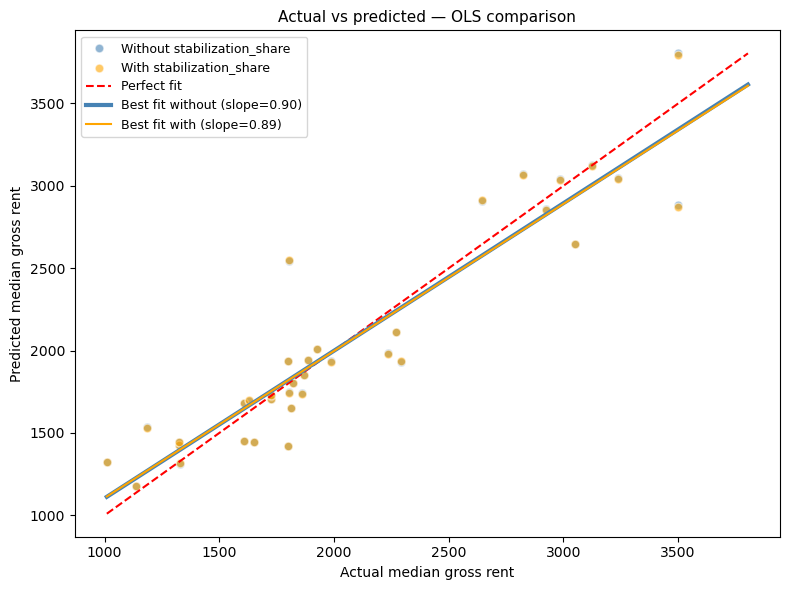

In [107]:
plt.figure(figsize=(8, 6))

ols_predictions_clean = np.array(ols_predictions_clean)
ols_predictions_new   = np.array(ols_predictions_new)

# Without stabilization_share
plt.scatter(Y_test, ols_predictions_clean, alpha=0.6, color='steelblue',
            s=40, edgecolors='white', label='Without stabilization_share')

# With stabilization_share
plt.scatter(Y_test, ols_predictions_new, alpha=0.6, color='orange',
            s=40, edgecolors='white', label='With stabilization_share')

# Perfect fit line
min_val = min(Y_test.min(), ols_predictions_clean.min(), ols_predictions_new.min())
max_val = max(Y_test.max(), ols_predictions_clean.max(), ols_predictions_new.max())
plt.plot([min_val, max_val], [min_val, max_val],
         color='red', linestyle='--', linewidth=1.5, label='Perfect fit')

# Best fit lines
m1, b1 = np.polyfit(Y_test, ols_predictions_clean, 1)
m2, b2 = np.polyfit(Y_test, ols_predictions_new, 1)
x_line = np.linspace(min_val, max_val, 100)

plt.plot(x_line, m1 * x_line + b1, color='steelblue',
         linewidth=3, linestyle='-', label=f'Best fit without (slope={m1:.2f})')
plt.plot(x_line, m2 * x_line + b2, color='orange',
         linewidth=1.5, linestyle='-', label=f'Best fit with (slope={m2:.2f})')

plt.title('Actual vs predicted — OLS comparison', fontsize=11)
plt.xlabel('Actual median gross rent')
plt.ylabel('Predicted median gross rent')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Scenario Analysis

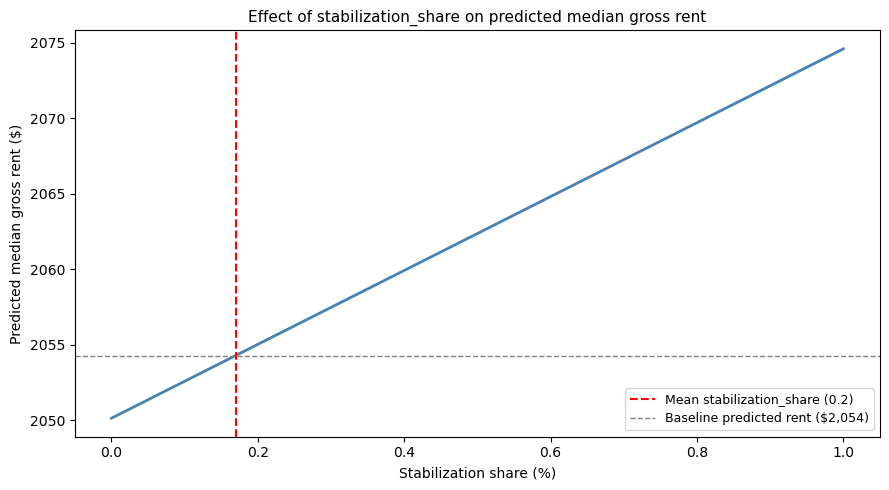


SCENARIO ANALYSIS — stabilization_share effect on predicted rent
  stabilization_share =   0  →  Predicted rent: $2,050.14
  stabilization_share = 0.1  →  Predicted rent: $2,052.59
  stabilization_share = 0.2  →  Predicted rent: $2,055.04
  stabilization_share = 0.3  →  Predicted rent: $2,057.48
  stabilization_share = 0.4  →  Predicted rent: $2,059.93
  stabilization_share = 0.5  →  Predicted rent: $2,062.38
  stabilization_share = 0.6  →  Predicted rent: $2,064.83
  stabilization_share = 0.7  →  Predicted rent: $2,067.27
  stabilization_share = 0.8  →  Predicted rent: $2,069.72
  stabilization_share = 0.9  →  Predicted rent: $2,072.17
  stabilization_share =   1  →  Predicted rent: $2,074.62


In [108]:
import numpy as np
import pandas as pd

# ======================================================================
# SCENARIO ANALYSIS — vary stabilization_share, hold others constant
# ======================================================================

# Use the mean values of all other features as the baseline
X_test_ols_new_df = pd.DataFrame(X_test, columns=X.columns)[survived_features_new]
baseline          = X_test_ols_new_df.mean()

# Range of stabilization_share values to test (0 to 100)
stab_values = np.linspace(0, 1, 200)

predicted_rents = []
for val in stab_values:
    scenario                       = baseline.copy()
    scenario['stabilization_share'] = val
    scenario_const                 = sm.add_constant(pd.DataFrame([scenario]), has_constant='add')
    pred                           = ols_model_new.predict(scenario_const)[0]
    predicted_rents.append(pred)

predicted_rents = np.array(predicted_rents)

# ======================================================================
# PLOT
# ======================================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.plot(stab_values, predicted_rents, color='steelblue', linewidth=2)
plt.axvline(baseline['stabilization_share'], color='red', linestyle='--',
            linewidth=1.5, label=f"Mean stabilization_share ({baseline['stabilization_share']:.1f})")
plt.axhline(baseline_rent := ols_model_new.predict(
                sm.add_constant(pd.DataFrame([baseline]), has_constant='add'))[0],
            color='gray', linestyle='--', linewidth=1,
            label=f'Baseline predicted rent (${baseline_rent:,.0f})')

plt.title('Effect of stabilization_share on predicted median gross rent', fontsize=11)
plt.xlabel('Stabilization share (%)')
plt.ylabel('Predicted median gross rent ($)')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ======================================================================
# PRINT KEY SCENARIOS
# ======================================================================
print("\n======================================================================")
print("SCENARIO ANALYSIS — stabilization_share effect on predicted rent")
print("======================================================================")
for val in [0, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1]:
    scenario                        = baseline.copy()
    scenario['stabilization_share'] = val
    scenario_const                  = sm.add_constant(pd.DataFrame([scenario]), has_constant='add')
    pred                            = ols_model_new.predict(scenario_const)[0]
    print(f"  stabilization_share = {val:>3}  →  Predicted rent: ${pred:,.2f}")
print("======================================================================")

In [109]:
print(df_model['stabilization_share'].describe())
print(f"\nMin : {df_model['stabilization_share'].min():.4f}")
print(f"Max : {df_model['stabilization_share'].max():.4f}")
print(f"Mean: {df_model['stabilization_share'].mean():.4f}")

count    175.000000
mean       0.209168
std        0.241931
min        0.000000
25%        0.000000
50%        0.060105
75%        0.407952
max        0.779829
Name: stabilization_share, dtype: float64

Min : 0.0000
Max : 0.7798
Mean: 0.2092


In [110]:
# Check for the multicollinearity

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Build the cleaned training data with all survived features + stabilization_share
X_vif = pd.DataFrame(X_train, columns=X.columns)[survived_features_new][non_influential_mask]
X_vif_const = sm.add_constant(X_vif)

# Calculate VIF for each feature
vif_data = pd.DataFrame({
    'Feature': X_vif_const.columns,
    'VIF'    : [variance_inflation_factor(X_vif_const.values, i)
                for i in range(X_vif_const.shape[1])]
})

# Exclude constant and sort
vif_data = vif_data[vif_data['Feature'] != 'const'].sort_values('VIF', ascending=False)

print("\n======================================================================")
print("VARIANCE INFLATION FACTOR (VIF)")
print("======================================================================")
for _, row in vif_data.iterrows():
    flag = ''
    if row['VIF'] > 10:
        flag = '  ← HIGH multicollinearity'
    elif row['VIF'] > 5:
        flag = '  ← moderate multicollinearity'
    print(f"  {row['Feature']:<35} VIF: {row['VIF']:>8.2f}{flag}")
print("======================================================================")


VARIANCE INFLATION FACTOR (VIF)
  homeownership_rate                  VIF:     4.30
  built_1990_1999                     VIF:     2.91
  rent_lt_10pct_income                VIF:     2.68
  built_2010_2019                     VIF:     2.50
  borough_Manhattan                   VIF:     2.46
  built_1980_1989                     VIF:     2.30
  vacancy_rate                        VIF:     2.26
  median_household_income             VIF:     2.13
  borough_Queens                      VIF:     2.04
  borough_Staten_Island               VIF:     2.01
  built_2020_or_later                 VIF:     1.81
  stabilization_share                 VIF:     1.80


# Check whether we have columns such as Zip and Predicted Rent prices

In [111]:
df_model.columns

Index(['rent_burden_total_renter_households', 'rent_lt_10pct_income',
       'rent_10_to_14_9pct_income', 'rent_15_to_19_9pct_income',
       'rent_20_to_24_9pct_income', 'rent_25_to_29_9pct_income',
       'rent_30_to_34_9pct_income', 'rent_35_to_39_9pct_income',
       'rent_40_to_49_9pct_income', 'rent_50pct_or_more_income',
       'housing_units_total', 'median_gross_rent', 'median_household_income',
       'occupancy_total_units', 'occupied_units', 'vacant_units',
       'tenure_total_occupied_units', 'owner_occupied_units',
       'renter_occupied_units', 'total_population', 'year_built_total_units',
       'built_2020_or_later', 'built_2010_2019', 'built_2000_2009',
       'built_1990_1999', 'built_1980_1989', 'built_1970_1979',
       'built_1960_1969', 'built_1950_1959', 'built_1940_1949',
       'built_1939_or_earlier', 'total_units', 'stabilized_units',
       'stabilized_buildings', 'total_buildings', 'stabilization_share',
       'vacancy_rate', 'homeownership_rate', 'new_

In [112]:
print(df_model.shape, '\n', '========== Data Result ==========')
df_model

(175, 45) 
 ========== Data Result ==========


,rent_burden_total_renter_households,rent_lt_10pct_income,rent_10_to_14_9pct_income,rent_15_to_19_9pct_income,rent_20_to_24_9pct_income,rent_25_to_29_9pct_income,rent_30_to_34_9pct_income,rent_35_to_39_9pct_income,rent_40_to_49_9pct_income,rent_50pct_or_more_income,housing_units_total,median_gross_rent,median_household_income,occupancy_total_units,occupied_units,vacant_units,tenure_total_occupied_units,owner_occupied_units,renter_occupied_units,total_population,year_built_total_units,built_2020_or_later,built_2010_2019,built_2000_2009,built_1990_1999,built_1980_1989,built_1970_1979,built_1960_1969,built_1950_1959,built_1940_1949,built_1939_or_earlier,total_units,stabilized_units,stabilized_buildings,total_buildings,stabilization_share,vacancy_rate,homeownership_rate,new_construction_share,renter_density,pre_war_share,borough_Brooklyn,borough_Manhattan,borough_Queens,borough_Staten_Island
0,11939.0,917.0,1502.0,1801.0,1484.0,1181.0,1074.0,546.0,892.0,2137.0,18356.0,3361.0,129852.0,18356.0,15737.0,2619.0,15737.0,3798.0,11939.0,30511.0,18356.0,280.0,5049.0,2404.0,296.0,590.0,423.0,3290.0,553.0,508.0,4963.0,22303.0,12310.0,127,356,0.551944,0.142678,0.206908,0.290314,0.650414,0.270375,0.0,1.0,0.0,0.0
1,29732.0,1688.0,2438.0,2857.0,3466.0,3197.0,3752.0,1338.0,2076.0,7758.0,40696.0,1229.0,48386.0,40696.0,36556.0,4140.0,36556.0,6824.0,29732.0,76873.0,40696.0,403.0,1940.0,1590.0,1313.0,2373.0,3566.0,4822.0,6003.0,2838.0,15848.0,36840.0,14431.0,601,1180,0.391721,0.101730,0.167682,0.057573,0.730588,0.389424,0.0,1.0,0.0,0.0
2,15410.0,1031.0,2255.0,1722.0,1455.0,1355.0,1147.0,1171.0,1148.0,3480.0,30413.0,3049.0,154262.0,30413.0,24503.0,5910.0,24503.0,9093.0,15410.0,53560.0,30413.0,50.0,683.0,989.0,558.0,1555.0,1560.0,4611.0,2456.0,1425.0,16526.0,33576.0,18652.0,602,1479,0.555516,0.194325,0.298984,0.024102,0.506691,0.543386,0.0,1.0,0.0,0.0
3,1060.0,21.0,119.0,255.0,84.0,39.0,128.0,72.0,136.0,206.0,2247.0,3501.0,250001.0,2247.0,1865.0,382.0,1865.0,805.0,1060.0,3711.0,2247.0,0.0,221.0,421.0,44.0,115.0,18.0,33.0,5.0,6.0,1384.0,4492.0,1248.0,5,37,0.277827,0.170004,0.358255,0.098353,0.471740,0.615932,0.0,1.0,0.0,0.0
4,4323.0,77.0,515.0,461.0,664.0,559.0,364.0,188.0,331.0,1164.0,6606.0,3501.0,190233.0,6606.0,5248.0,1358.0,5248.0,925.0,4323.0,9439.0,6606.0,0.0,161.0,841.0,601.0,125.0,515.0,393.0,339.0,218.0,3413.0,6871.0,2923.0,8,25,0.425411,0.205571,0.140024,0.024372,0.654405,0.516652,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,2294.0,102.0,154.0,167.0,272.0,136.0,140.0,98.0,160.0,912.0,6843.0,2171.0,88047.0,6843.0,6568.0,275.0,6568.0,4274.0,2294.0,22527.0,6843.0,0.0,181.0,418.0,255.0,310.0,275.0,1108.0,800.0,828.0,2668.0,6650.0,4.0,1,4246,0.000602,0.040187,0.624580,0.026450,0.335233,0.389887,0.0,0.0,1.0,0.0
173,16665.0,1049.0,1126.0,915.0,1993.0,1893.0,1332.0,1320.0,1426.0,4702.0,24072.0,1425.0,56135.0,24072.0,23039.0,1033.0,23039.0,6374.0,16665.0,69359.0,24072.0,276.0,925.0,2531.0,1196.0,1430.0,4074.0,3541.0,4225.0,1461.0,4413.0,24882.0,9036.0,156,5608,0.363154,0.042913,0.264789,0.049892,0.692298,0.183325,0.0,0.0,1.0,0.0
174,5400.0,342.0,471.0,405.0,408.0,251.0,426.0,560.0,412.0,1734.0,8415.0,1161.0,49720.0,8415.0,8070.0,345.0,8070.0,2670.0,5400.0,22734.0,8415.0,135.0,1175.0,1307.0,361.0,275.0,1368.0,1223.0,1205.0,382.0,984.0,8348.0,83.0,16,2083,0.009943,0.040998,0.317291,0.155674,0.641711,0.116934,0.0,0.0,1.0,0.0
175,2847.0,112.0,238.0,240.0,301.0,375.0,220.0,87.0,171.0,907.0,5922.0,1216.0,68449.0,5922.0,5559.0,363.0,5559.0,2712.0,2847.0,13244.0,5922.0,0.0,377.0,811.0,406.0,71.0,495.0,1128.0,997.0,520.0,1117.0,4727.0,340.0,48,1526,0.071927,0.061297,0.457953,0.063661,0.480750,0.188619,0.0,0.0,1.0,0.0


# Integrate Two Columns: Predicted Rent w/ and w/out the Intensity Variable

In [113]:
X_all_new       = df_model[survived_features_new]
X_all_new_const = sm.add_constant(X_all_new, has_constant='add')
df_model['pred_rent_w_stab'] = ols_model_new.predict(X_all_new_const)

# 2. Predictions from ols_model_clean (without stabilization_share)
X_all_clean       = df_model[survived_features]
X_all_clean_const = sm.add_constant(X_all_clean, has_constant='add')
df_model['pred_rent_clean_wo_stab'] = ols_model_clean.predict(X_all_clean_const)

In [114]:
print(df_model[['median_gross_rent', 'pred_rent_w_stab', 'pred_rent_clean_wo_stab']].head(10))
print(f"\nShape: {df_model.shape}")

   median_gross_rent  pred_rent_w_stab  pred_rent_clean_wo_stab
0             3361.0       2711.443289              2705.794811
1             1229.0       1455.725478              1453.691564
2             3049.0       2848.498181              2840.188083
3             3501.0       3977.685802              3980.524769
4             3501.0       3310.668944              3311.961132
5             3501.0       3338.265593              3338.509604
6             3501.0       3975.073623              3975.855703
7             2006.0       1986.415722              1981.188769
8             3326.0       2774.866747              2768.561186
9             3050.0       2644.247249              2646.816349

Shape: (175, 47)


In [115]:
df_model

,rent_burden_total_renter_households,rent_lt_10pct_income,rent_10_to_14_9pct_income,rent_15_to_19_9pct_income,rent_20_to_24_9pct_income,rent_25_to_29_9pct_income,rent_30_to_34_9pct_income,rent_35_to_39_9pct_income,rent_40_to_49_9pct_income,rent_50pct_or_more_income,housing_units_total,median_gross_rent,median_household_income,occupancy_total_units,occupied_units,vacant_units,tenure_total_occupied_units,owner_occupied_units,renter_occupied_units,total_population,year_built_total_units,built_2020_or_later,built_2010_2019,built_2000_2009,built_1990_1999,built_1980_1989,built_1970_1979,built_1960_1969,built_1950_1959,built_1940_1949,built_1939_or_earlier,total_units,stabilized_units,stabilized_buildings,total_buildings,stabilization_share,vacancy_rate,homeownership_rate,new_construction_share,renter_density,pre_war_share,borough_Brooklyn,borough_Manhattan,borough_Queens,borough_Staten_Island,pred_rent_w_stab,pred_rent_clean_wo_stab
0,11939.0,917.0,1502.0,1801.0,1484.0,1181.0,1074.0,546.0,892.0,2137.0,18356.0,3361.0,129852.0,18356.0,15737.0,2619.0,15737.0,3798.0,11939.0,30511.0,18356.0,280.0,5049.0,2404.0,296.0,590.0,423.0,3290.0,553.0,508.0,4963.0,22303.0,12310.0,127,356,0.551944,0.142678,0.206908,0.290314,0.650414,0.270375,0.0,1.0,0.0,0.0,2711.443289,2705.794811
1,29732.0,1688.0,2438.0,2857.0,3466.0,3197.0,3752.0,1338.0,2076.0,7758.0,40696.0,1229.0,48386.0,40696.0,36556.0,4140.0,36556.0,6824.0,29732.0,76873.0,40696.0,403.0,1940.0,1590.0,1313.0,2373.0,3566.0,4822.0,6003.0,2838.0,15848.0,36840.0,14431.0,601,1180,0.391721,0.101730,0.167682,0.057573,0.730588,0.389424,0.0,1.0,0.0,0.0,1455.725478,1453.691564
2,15410.0,1031.0,2255.0,1722.0,1455.0,1355.0,1147.0,1171.0,1148.0,3480.0,30413.0,3049.0,154262.0,30413.0,24503.0,5910.0,24503.0,9093.0,15410.0,53560.0,30413.0,50.0,683.0,989.0,558.0,1555.0,1560.0,4611.0,2456.0,1425.0,16526.0,33576.0,18652.0,602,1479,0.555516,0.194325,0.298984,0.024102,0.506691,0.543386,0.0,1.0,0.0,0.0,2848.498181,2840.188083
3,1060.0,21.0,119.0,255.0,84.0,39.0,128.0,72.0,136.0,206.0,2247.0,3501.0,250001.0,2247.0,1865.0,382.0,1865.0,805.0,1060.0,3711.0,2247.0,0.0,221.0,421.0,44.0,115.0,18.0,33.0,5.0,6.0,1384.0,4492.0,1248.0,5,37,0.277827,0.170004,0.358255,0.098353,0.471740,0.615932,0.0,1.0,0.0,0.0,3977.685802,3980.524769
4,4323.0,77.0,515.0,461.0,664.0,559.0,364.0,188.0,331.0,1164.0,6606.0,3501.0,190233.0,6606.0,5248.0,1358.0,5248.0,925.0,4323.0,9439.0,6606.0,0.0,161.0,841.0,601.0,125.0,515.0,393.0,339.0,218.0,3413.0,6871.0,2923.0,8,25,0.425411,0.205571,0.140024,0.024372,0.654405,0.516652,0.0,1.0,0.0,0.0,3310.668944,3311.961132
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,2294.0,102.0,154.0,167.0,272.0,136.0,140.0,98.0,160.0,912.0,6843.0,2171.0,88047.0,6843.0,6568.0,275.0,6568.0,4274.0,2294.0,22527.0,6843.0,0.0,181.0,418.0,255.0,310.0,275.0,1108.0,800.0,828.0,2668.0,6650.0,4.0,1,4246,0.000602,0.040187,0.624580,0.026450,0.335233,0.389887,0.0,0.0,1.0,0.0,1822.770781,1824.247843
173,16665.0,1049.0,1126.0,915.0,1993.0,1893.0,1332.0,1320.0,1426.0,4702.0,24072.0,1425.0,56135.0,24072.0,23039.0,1033.0,23039.0,6374.0,16665.0,69359.0,24072.0,276.0,925.0,2531.0,1196.0,1430.0,4074.0,3541.0,4225.0,1461.0,4413.0,24882.0,9036.0,156,5608,0.363154,0.042913,0.264789,0.049892,0.692298,0.183325,0.0,0.0,1.0,0.0,1542.383837,1537.395902
174,5400.0,342.0,471.0,405.0,408.0,251.0,426.0,560.0,412.0,1734.0,8415.0,1161.0,49720.0,8415.0,8070.0,345.0,8070.0,2670.0,5400.0,22734.0,8415.0,135.0,1175.0,1307.0,361.0,275.0,1368.0,1223.0,1205.0,382.0,984.0,8348.0,83.0,16,2083,0.009943,0.040998,0.317291,0.155674,0.641711,0.116934,0.0,0.0,1.0,0.0,1506.749431,1511.908666
175,2847.0,112.0,238.0,240.0,301.0,375.0,220.0,87.0,171.0,907.0,5922.0,1216.0,68449.0,5922.0,5559.0,363.0,5559.0,2712.0,2847.0,13244.0,5922.0,0.0,377.0,811.0,406.0,71.0,495.0,1128.0,997.0,520.0,1117.0,4727.0,340.0,48,1526,0.071927,0.061297,0

In [116]:
# df_model still has the original df_merged index (dropna preserves it)
df_model['zip'] = df_merged.loc[df_model.index, 'zip']

# Verify
print(df_model[['zip', 'median_gross_rent',
                'pred_rent_w_stab', 'pred_rent_clean_wo_stab']].head(10))
print(f"\nNull zipcodes: {df_model['zip'].isna().sum()}")

     zip  median_gross_rent  pred_rent_w_stab  pred_rent_clean_wo_stab
0  10001             3361.0       2711.443289              2705.794811
1  10002             1229.0       1455.725478              1453.691564
2  10003             3049.0       2848.498181              2840.188083
3  10004             3501.0       3977.685802              3980.524769
4  10005             3501.0       3310.668944              3311.961132
5  10006             3501.0       3338.265593              3338.509604
6  10007             3501.0       3975.073623              3975.855703
7  10009             2006.0       1986.415722              1981.188769
8  10010             3326.0       2774.866747              2768.561186
9  10011             3050.0       2644.247249              2646.816349

Null zipcodes: 0


In [117]:
df_model

,rent_burden_total_renter_households,rent_lt_10pct_income,rent_10_to_14_9pct_income,rent_15_to_19_9pct_income,rent_20_to_24_9pct_income,rent_25_to_29_9pct_income,rent_30_to_34_9pct_income,rent_35_to_39_9pct_income,rent_40_to_49_9pct_income,rent_50pct_or_more_income,housing_units_total,median_gross_rent,median_household_income,occupancy_total_units,occupied_units,vacant_units,tenure_total_occupied_units,owner_occupied_units,renter_occupied_units,total_population,year_built_total_units,built_2020_or_later,built_2010_2019,built_2000_2009,built_1990_1999,built_1980_1989,built_1970_1979,built_1960_1969,built_1950_1959,built_1940_1949,built_1939_or_earlier,total_units,stabilized_units,stabilized_buildings,total_buildings,stabilization_share,vacancy_rate,homeownership_rate,new_construction_share,renter_density,pre_war_share,borough_Brooklyn,borough_Manhattan,borough_Queens,borough_Staten_Island,pred_rent_w_stab,pred_rent_clean_wo_stab,zip
0,11939.0,917.0,1502.0,1801.0,1484.0,1181.0,1074.0,546.0,892.0,2137.0,18356.0,3361.0,129852.0,18356.0,15737.0,2619.0,15737.0,3798.0,11939.0,30511.0,18356.0,280.0,5049.0,2404.0,296.0,590.0,423.0,3290.0,553.0,508.0,4963.0,22303.0,12310.0,127,356,0.551944,0.142678,0.206908,0.290314,0.650414,0.270375,0.0,1.0,0.0,0.0,2711.443289,2705.794811,10001
1,29732.0,1688.0,2438.0,2857.0,3466.0,3197.0,3752.0,1338.0,2076.0,7758.0,40696.0,1229.0,48386.0,40696.0,36556.0,4140.0,36556.0,6824.0,29732.0,76873.0,40696.0,403.0,1940.0,1590.0,1313.0,2373.0,3566.0,4822.0,6003.0,2838.0,15848.0,36840.0,14431.0,601,1180,0.391721,0.101730,0.167682,0.057573,0.730588,0.389424,0.0,1.0,0.0,0.0,1455.725478,1453.691564,10002
2,15410.0,1031.0,2255.0,1722.0,1455.0,1355.0,1147.0,1171.0,1148.0,3480.0,30413.0,3049.0,154262.0,30413.0,24503.0,5910.0,24503.0,9093.0,15410.0,53560.0,30413.0,50.0,683.0,989.0,558.0,1555.0,1560.0,4611.0,2456.0,1425.0,16526.0,33576.0,18652.0,602,1479,0.555516,0.194325,0.298984,0.024102,0.506691,0.543386,0.0,1.0,0.0,0.0,2848.498181,2840.188083,10003
3,1060.0,21.0,119.0,255.0,84.0,39.0,128.0,72.0,136.0,206.0,2247.0,3501.0,250001.0,2247.0,1865.0,382.0,1865.0,805.0,1060.0,3711.0,2247.0,0.0,221.0,421.0,44.0,115.0,18.0,33.0,5.0,6.0,1384.0,4492.0,1248.0,5,37,0.277827,0.170004,0.358255,0.098353,0.471740,0.615932,0.0,1.0,0.0,0.0,3977.685802,3980.524769,10004
4,4323.0,77.0,515.0,461.0,664.0,559.0,364.0,188.0,331.0,1164.0,6606.0,3501.0,190233.0,6606.0,5248.0,1358.0,5248.0,925.0,4323.0,9439.0,6606.0,0.0,161.0,841.0,601.0,125.0,515.0,393.0,339.0,218.0,3413.0,6871.0,2923.0,8,25,0.425411,0.205571,0.140024,0.024372,0.654405,0.516652,0.0,1.0,0.0,0.0,3310.668944,3311.961132,10005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,2294.0,102.0,154.0,167.0,272.0,136.0,140.0,98.0,160.0,912.0,6843.0,2171.0,88047.0,6843.0,6568.0,275.0,6568.0,4274.0,2294.0,22527.0,6843.0,0.0,181.0,418.0,255.0,310.0,275.0,1108.0,800.0,828.0,2668.0,6650.0,4.0,1,4246,0.000602,0.040187,0.624580,0.026450,0.335233,0.389887,0.0,0.0,1.0,0.0,1822.770781,1824.247843,11436
173,16665.0,1049.0,1126.0,915.0,1993.0,1893.0,1332.0,1320.0,1426.0,4702.0,24072.0,1425.0,56135.0,24072.0,23039.0,1033.0,23039.0,6374.0,16665.0,69359.0,24072.0,276.0,925.0,2531.0,1196.0,1430.0,4074.0,3541.0,4225.0,1461.0,4413.0,24882.0,9036.0,156,5608,0.363154,0.042913,0.264789,0.049892,0.692298,0.183325,0.0,0.0,1.0,0.0,1542.383837,1537.395902,11691
174,5400.0,342.0,471.0,405.0,408.0,251.0,426.0,560.0,412.0,1734.0,8415.0,1161.0,49720.0,8415.0,8070.0,345.0,8070.0,2670.0,5400.0,22734.0,8415.0,135.0,1175.0,1307.0,361.0,275.0,1368.0,1223.0,1205.0,382.0,984.0,8348.0,83.0,16,2083,0.009943,0.040998,0.317291,0.155674,0.641711,0.116934,0.0,0.0,1.0,0.0,1506.749431,1511.908666,11692
175,2847.0,112.0,238.0,240.0,301.0,375.0,220.0,87.0,171.0,907.0,5922.0,1216.0,68449.0,5922.0,5559.0,363.0,5559.0,2712.0,2847.0,13244.0,5922.0,0.0,377.0,811.0,406.0,71.0,495.0,1128.0,997

In [118]:
cols = ['zip'] + [col for col in df_model.columns if col != 'zip']
df_model = df_model[cols]

# Verify
print(df_model.columns.tolist()[:5])

['zip', 'rent_burden_total_renter_households', 'rent_lt_10pct_income', 'rent_10_to_14_9pct_income', 'rent_15_to_19_9pct_income']


In [119]:
df_model

,zip,rent_burden_total_renter_households,rent_lt_10pct_income,rent_10_to_14_9pct_income,rent_15_to_19_9pct_income,rent_20_to_24_9pct_income,rent_25_to_29_9pct_income,rent_30_to_34_9pct_income,rent_35_to_39_9pct_income,rent_40_to_49_9pct_income,rent_50pct_or_more_income,housing_units_total,median_gross_rent,median_household_income,occupancy_total_units,occupied_units,vacant_units,tenure_total_occupied_units,owner_occupied_units,renter_occupied_units,total_population,year_built_total_units,built_2020_or_later,built_2010_2019,built_2000_2009,built_1990_1999,built_1980_1989,built_1970_1979,built_1960_1969,built_1950_1959,built_1940_1949,built_1939_or_earlier,total_units,stabilized_units,stabilized_buildings,total_buildings,stabilization_share,vacancy_rate,homeownership_rate,new_construction_share,renter_density,pre_war_share,borough_Brooklyn,borough_Manhattan,borough_Queens,borough_Staten_Island,pred_rent_w_stab,pred_rent_clean_wo_stab
0,10001,11939.0,917.0,1502.0,1801.0,1484.0,1181.0,1074.0,546.0,892.0,2137.0,18356.0,3361.0,129852.0,18356.0,15737.0,2619.0,15737.0,3798.0,11939.0,30511.0,18356.0,280.0,5049.0,2404.0,296.0,590.0,423.0,3290.0,553.0,508.0,4963.0,22303.0,12310.0,127,356,0.551944,0.142678,0.206908,0.290314,0.650414,0.270375,0.0,1.0,0.0,0.0,2711.443289,2705.794811
1,10002,29732.0,1688.0,2438.0,2857.0,3466.0,3197.0,3752.0,1338.0,2076.0,7758.0,40696.0,1229.0,48386.0,40696.0,36556.0,4140.0,36556.0,6824.0,29732.0,76873.0,40696.0,403.0,1940.0,1590.0,1313.0,2373.0,3566.0,4822.0,6003.0,2838.0,15848.0,36840.0,14431.0,601,1180,0.391721,0.101730,0.167682,0.057573,0.730588,0.389424,0.0,1.0,0.0,0.0,1455.725478,1453.691564
2,10003,15410.0,1031.0,2255.0,1722.0,1455.0,1355.0,1147.0,1171.0,1148.0,3480.0,30413.0,3049.0,154262.0,30413.0,24503.0,5910.0,24503.0,9093.0,15410.0,53560.0,30413.0,50.0,683.0,989.0,558.0,1555.0,1560.0,4611.0,2456.0,1425.0,16526.0,33576.0,18652.0,602,1479,0.555516,0.194325,0.298984,0.024102,0.506691,0.543386,0.0,1.0,0.0,0.0,2848.498181,2840.188083
3,10004,1060.0,21.0,119.0,255.0,84.0,39.0,128.0,72.0,136.0,206.0,2247.0,3501.0,250001.0,2247.0,1865.0,382.0,1865.0,805.0,1060.0,3711.0,2247.0,0.0,221.0,421.0,44.0,115.0,18.0,33.0,5.0,6.0,1384.0,4492.0,1248.0,5,37,0.277827,0.170004,0.358255,0.098353,0.471740,0.615932,0.0,1.0,0.0,0.0,3977.685802,3980.524769
4,10005,4323.0,77.0,515.0,461.0,664.0,559.0,364.0,188.0,331.0,1164.0,6606.0,3501.0,190233.0,6606.0,5248.0,1358.0,5248.0,925.0,4323.0,9439.0,6606.0,0.0,161.0,841.0,601.0,125.0,515.0,393.0,339.0,218.0,3413.0,6871.0,2923.0,8,25,0.425411,0.205571,0.140024,0.024372,0.654405,0.516652,0.0,1.0,0.0,0.0,3310.668944,3311.961132
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,11436,2294.0,102.0,154.0,167.0,272.0,136.0,140.0,98.0,160.0,912.0,6843.0,2171.0,88047.0,6843.0,6568.0,275.0,6568.0,4274.0,2294.0,22527.0,6843.0,0.0,181.0,418.0,255.0,310.0,275.0,1108.0,800.0,828.0,2668.0,6650.0,4.0,1,4246,0.000602,0.040187,0.624580,0.026450,0.335233,0.389887,0.0,0.0,1.0,0.0,1822.770781,1824.247843
173,11691,16665.0,1049.0,1126.0,915.0,1993.0,1893.0,1332.0,1320.0,1426.0,4702.0,24072.0,1425.0,56135.0,24072.0,23039.0,1033.0,23039.0,6374.0,16665.0,69359.0,24072.0,276.0,925.0,2531.0,1196.0,1430.0,4074.0,3541.0,4225.0,1461.0,4413.0,24882.0,9036.0,156,5608,0.363154,0.042913,0.264789,0.049892,0.692298,0.183325,0.0,0.0,1.0,0.0,1542.383837,1537.395902
174,11692,5400.0,342.0,471.0,405.0,408.0,251.0,426.0,560.0,412.0,1734.0,8415.0,1161.0,49720.0,8415.0,8070.0,345.0,8070.0,2670.0,5400.0,22734.0,8415.0,135.0,1175.0,1307.0,361.0,275.0,1368.0,1223.0,1205.0,382.0,984.0,8348.0,83.0,16,2083,0.009943,0.040998,0.317291,0.155674,0.641711,0.116934,0.0,0.0,1.0,0.0,1506.749431,1511.908666
175,11693,2847.0,112.0,238.0,240.0,301.0,375.0,220.0,87.0,171.0,907.0,5922.0,1216.0,68449.0,5922.0,5559.0,363.0,5559.0,2712.0,2847.0,13244.0,5922.0,0.0,377.0,811.0,406.0,71.0,495.0,1128

In [120]:
df_model.to_csv("Revised - Merged Housing Dataset (by ZipCode) with rent prediction_edit3.csv")

# Data Sanity Check

In [103]:
print(f"Total rows    : {len(df_model)}")
print(f"Index min     : {df_model.index.min()}")
print(f"Index max     : {df_model.index.max()}")
print(f"Is continuous : {df_model.index.is_monotonic_increasing}")
print(f"\nMissing indices from df_merged:")
missing = set(df_merged.index) - set(df_model.index)
print(missing)

Total rows    : 175
Index min     : 0
Index max     : 176
Is continuous : True

Missing indices from df_merged:
{17, 42, 177}
